## 1. Загрузка исходных данных


In [1]:
import sqlite3
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

print("=== 1. Подключение к БД и чтение таблиц ===")
conn = sqlite3.connect('shop_database.db')

tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)
print("Таблицы в БД:")
print(tables)

for table in ['personal_data', 'personal_data_coeffs', 'purchases']:
    print(f"\n{'='*50}")
    print(f"Таблица: {table}")
    print('='*50)

    info = pd.read_sql(f"PRAGMA table_info({table})", conn)
    print("Колонки:")
    print(info)

    print("\nПервые 5 строк:")
    df = pd.read_sql(f"SELECT * FROM {table} LIMIT 5", conn)
    print(df)

    count = pd.read_sql(f"SELECT COUNT(*) as count FROM {table}", conn)
    print(f"\nВсего строк: {count['count'].values[0]}")

conn.close()


print("\n\n=== 2. Чтение personal_data.csv (утерянные данные) ===")

# По условию задачи файл поставляется СЖАТЫМ — personal_data.csv.gz
# (лежит в data.zip / result_data). Делаем загрузку устойчивой к обоим
# вариантам, на случай если архив был распакован вручную.
def load_personal_csv(path_base='personal_data'):
    """Читает personal_data.csv или personal_data.csv.gz — какой файл ни лежал бы рядом."""
    gz_path = f'{path_base}.csv.gz'
    csv_path = f'{path_base}.csv'
    if os.path.exists(gz_path):
        return pd.read_csv(gz_path, compression='gzip')
    elif os.path.exists(csv_path):
        return pd.read_csv(csv_path)
    else:
        raise FileNotFoundError(
            f"Не найден ни {csv_path}, ни {gz_path}. Проверьте, что архив data.zip "
            f"(папка result_data) распакован и файл лежит рядом с ноутбуком."
        )

personal_csv = load_personal_csv()
print(f"Размер: {personal_csv.shape}")
print("\nКолонки:", personal_csv.columns.tolist())
print("\nПервые 5 строк:")
print(personal_csv.head())
print("\nТипы данных:")
print(personal_csv.dtypes)
print("\nПропуски:")
print(personal_csv.isna().sum())


print("\n\n=== 3. Чтение ID файлов ===")

def read_ids(path):
    ids = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            for word in line.split():
                try:
                    ids.append(int(word))
                except ValueError:
                    pass  # пропускаем заголовки/нечисловой текст
    return ids

ids_pos_list = read_ids('ids_first_company_positive.txt')
ids_neg_list = read_ids('ids_first_company_negative.txt')

ids_pos = pd.DataFrame({'id': ids_pos_list})
ids_neg = pd.DataFrame({'id': ids_neg_list})

print(f"Positive IDs: {len(ids_pos)} записей")
print(f"Negative IDs: {len(ids_neg)} записей")
print(f"\nПервые 10 positive ID: {ids_pos['id'].head(10).tolist()}")
print(f"Первые 10 negative ID: {ids_neg['id'].head(10).tolist()}")

print("\n\n=== ВСЕ ДАННЫЕ УСПЕШНО ЗАГРУЖЕНЫ ===")


=== 1. Подключение к БД и чтение таблиц ===
Таблицы в БД:
                   name
0             purchases
1  personal_data_coeffs
2         personal_data

Таблица: personal_data
Колонки:
   cid       name     type  notnull dflt_value  pk
0    0         id  INTEGER        0       None   0
1    1     gender  INTEGER        0       None   0
2    2        age  INTEGER        0       None   0
3    3  education     TEXT        0       None   0
4    4       city  INTEGER        0       None   0
5    5    country  INTEGER        0       None   0

Первые 5 строк:
   id  gender  age education  city  country
0   0       0   36   среднее  1201       32
1   4       0   35   среднее  1134       32
2   6       1   52   среднее  1188       32
3   7       0   37   среднее  1198       32
4   9       0   48   среднее  1134       32

Всего строк: 89241

Таблица: personal_data_coeffs
Колонки:
   cid           name     type  notnull dflt_value  pk
0    0             id  INTEGER        0       None   0
1    

## 2. Очистка текстовых признаков (товар, цвет)

По условию задачи: «информация о названии товаров неоднородна, а в данных о цветах попадаются наборы цветов, записанные через косую черту (/)». Это отдельный критерий оценки («корректно обработаны текстовые признаки»), поэтому обработка делается один раз здесь, а дальше по ноутбуку везде используется `purchases_clean`, а не «сырая» таблица `purchases`.


In [2]:
import re
import unicodedata

print("=== Очистка текстовых признаков в таблице purchases ===")
conn = sqlite3.connect('shop_database.db')
purchases_raw = pd.read_sql("SELECT * FROM purchases", conn)
conn.close()

print(f"Строк в purchases: {len(purchases_raw)}")
print("Пропуски по столбцам:")
print(purchases_raw.isna().sum())

purchases_clean = purchases_raw.copy()

# --- 1. Название товара: нормализация регистра, Unicode, пробелов и пунктуации ---
def normalize_product_name(name):
    if pd.isna(name):
        return np.nan
    name = unicodedata.normalize('NFKC', str(name)).strip().casefold()
    name = name.replace('ё', 'е')
    name = name.replace('–', '-').replace('—', '-').replace('−', '-')
    name = name.replace(' ', ' ')
    name = name.translate(str.maketrans({'«': '', '»': '', '"': '', "'": ''}))
    # Убираем лишнюю пунктуацию, но сохраняем дефисы и slash, если они могут
    # быть частью технического названия товара.
    # ИСПРАВЛЕНО: десятичная точка между цифрами (напр. '2.0', '5.11')
    # раньше уничтожалась общей чисткой пунктуации и превращалась
    # в '2 0' — временно защищаем её буквенным плейсхолдером.
    name = re.sub(r'(?<=\d)\.(?=\d)', 'dotph', name)
    name = re.sub(r'[^\w\s\-/№]+', ' ', name, flags=re.UNICODE)
    name = re.sub(r'\s*[-/]\s*', lambda m: m.group(0).strip(), name)
    name = re.sub(r'\s+', ' ', name).strip()
    name = name.replace('dotph', '.')
    return name.title()

if 'product' in purchases_clean.columns:
    purchases_clean['product'] = purchases_clean['product'].apply(normalize_product_name)

# --- 2. Цвет: приводим к списку отдельных цветов и сохраняем основной цвет ---
def split_colors(value):
    if pd.isna(value):
        return []
    parts = [x.strip().casefold() for x in str(value).split('/') if x.strip()]
    return list(dict.fromkeys(parts))

# ВАЖНО: в таблице БД столбец называется 'colour' (а не 'color'). Проверяем
# оба варианта написания, чтобы обработка цветов реально выполнялась.
color_col = 'colour' if 'colour' in purchases_clean.columns else (
    'color' if 'color' in purchases_clean.columns else None
)
if color_col is not None:
    purchases_clean['color_list'] = purchases_clean[color_col].apply(split_colors)
    purchases_clean['color_primary'] = purchases_clean['color_list'].apply(
        lambda x: x[0] if x else np.nan
    )
    purchases_clean['is_multicolor'] = purchases_clean['color_list'].apply(lambda x: len(x) > 1)

print("\nПропуски после очистки:")
print(purchases_clean.isna().sum())
print("\nПример очищенных товаров:")
print(purchases_clean[['product']].drop_duplicates().head(20) if 'product' in purchases_clean.columns else 'Колонка product не найдена')
print("\n=== ОЧИСТКА ЗАВЕРШЕНА ===")


=== Очистка текстовых признаков в таблице purchases ===
Строк в purchases: 786260
Пропуски по столбцам:
id                  0
product             0
colour         119524
cost                0
product_sex    314712
base_sale           0
dt                  0
dtype: int64

Пропуски после очистки:
id                    0
product               0
colour           119524
cost                  0
product_sex      314712
base_sale             0
dt                    0
color_list            0
color_primary    119524
is_multicolor         0
dtype: int64

Пример очищенных товаров:
                                              product
0          Велосипед Горный Женский Stern Mira 2.0 26
1                                     Стол Outventure
2                       Набор Outventure Стол 4 Стула
3                             Бутсы Мужские Gsd Astro
4   Мяч Футбольный Puma Teamfinal 21.2 Fifa Qualit...
5                             Кеды Мужские Fila A-Low
6                Полуботинки Мужские Outventur

## 3. Подготовка данных для классификации пола (train / predict наборы)


In [3]:
print("=== 1. Загрузка и фильтрация данных (Страна 32) ===")
conn = sqlite3.connect('shop_database.db')

# Загружаем и сразу фильтруем по стране 32 (ключевое требование ТЗ:
# "оставить только тех людей, которые относятся к стране 32")
personal_data_db = pd.read_sql("SELECT * FROM personal_data WHERE country == 32", conn)
coeffs = pd.read_sql("SELECT * FROM personal_data_coeffs", conn)
conn.close()

print(f"personal_data (страна 32): {len(personal_data_db)} строк")

# Объединяем с коэффициентами
df_train_base = pd.merge(personal_data_db, coeffs, on='id', how='left')
print(f"После объединения с коэффициентами: {len(df_train_base)} строк")


print("\n=== 2. Анализ пропусков и категориальных признаков ===")
print("Пропуски в df_train_base:")
print(df_train_base.isna().sum())

print("\nУникальные значения в 'education' (с количеством):")
print(df_train_base['education'].value_counts(dropna=False))


print("\n=== 3. Агрегация данных о покупках для создания новых признаков ===")
# Используем purchases_clean (очищенные названия товаров), а не «сырую» purchases.
purchase_stats = purchases_clean.groupby('id').agg(
    total_purchases=('id', 'count'),          # Общее количество покупок
    avg_cost=('cost', 'mean'),                # Средняя стоимость покупки
    total_cost=('cost', 'sum'),               # Общая сумма покупок
    sale_ratio=('base_sale', 'mean')          # Доля покупок, сделанных со скидкой
).reset_index()

print("Статистика покупок создана. Пример:")
print(purchase_stats.head())

# Объединяем статистику покупок с основными данными
df_train_full = pd.merge(df_train_base, purchase_stats, on='id', how='left')

# Заполняем пропуски в статистике покупок нулями (если у клиента не было покупок в базе)
for col in ['total_purchases', 'avg_cost', 'total_cost', 'sale_ratio']:
    df_train_full[col] = df_train_full[col].fillna(0)

print(f"\nИтоговый набор для ОБУЧЕНИЯ модели (df_train_full): {df_train_full.shape}")
print("Пропуски в итоговом наборе для обучения:")
print(df_train_full.isna().sum())


print("\n=== 4. Подготовка данных для ПРЕДСКАЗАНИЯ (personal_data.csv) ===")
# personal_csv уже был загружен устойчивым способом в первой ячейке
# (load_personal_csv поддерживает и .csv, и .csv.gz).
personal_csv_32 = personal_csv[personal_csv['country'] == 32].copy()

df_predict_base = pd.merge(personal_csv_32, coeffs, on='id', how='left')
df_predict_full = pd.merge(df_predict_base, purchase_stats, on='id', how='left')

# Заполняем пропуски в статистике покупок нулями
for col in ['total_purchases', 'avg_cost', 'total_cost', 'sale_ratio']:
    df_predict_full[col] = df_predict_full[col].fillna(0)

print(f"Итоговый набор для ПРЕДСКАЗАНИЯ (df_predict_full): {df_predict_full.shape}")
print("Пропуски в наборе для предсказания:")
print(df_predict_full.isna().sum())

print("\n=== ДАННЫЕ ПОДГОТОВЛЕНЫ ===")


=== 1. Загрузка и фильтрация данных (Страна 32) ===
personal_data (страна 32): 88786 строк
После объединения с коэффициентами: 88786 строк

=== 2. Анализ пропусков и категориальных признаков ===
Пропуски в df_train_base:
id               0
gender           0
age              0
education        0
city             0
country          0
lbt_coef         0
ac_coef          0
sm_coef          0
personal_coef    0
dtype: int64

Уникальные значения в 'education' (с количеством):
education
среднее    69539
высшее     19247
Name: count, dtype: int64

=== 3. Агрегация данных о покупках для создания новых признаков ===
Статистика покупок создана. Пример:
   id  total_purchases     avg_cost  total_cost  sale_ratio
0   0                3  6632.333333       19897    0.333333
1   3                4  3649.000000       14596    0.250000
2   4                7  4441.857143       31093    0.000000
3   6               15  5605.666667       84085    0.400000
4   7               13  4525.153846       58827  

## 4. Классификация пола клиентов (Random Forest + GridSearchCV, метрика F1)


=== 1. Кодирование и подготовка признаков ===
=== 2. Очистка данных ===
=== 3. Разбиение на train/test ===
Train: (71028, 11), Test: (17758, 11)
Проверка X на inf и NaN:
Есть inf? False
Есть NaN? False

=== 4. Обучение базовой модели Random Forest ===
F1-score (macro): 1.0000
F1-score (weighted): 1.0000

=== 5. Подбор гиперпараметров (GridSearchCV) ===
Fitting 3 folds for each of 24 candidates, totalling 72 fits

Лучшие параметры: {'max_depth': 8, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Лучший F1-score на кросс-валидации: 1.0000
F1-score лучших параметров на тесте: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7576
           1       1.00      1.00      1.00     10182

    accuracy                           1.00     17758
   macro avg       1.00      1.00      1.00     17758
weighted avg       1.00      1.00      1.00     17758


=== 6. Важность признаков ===
           

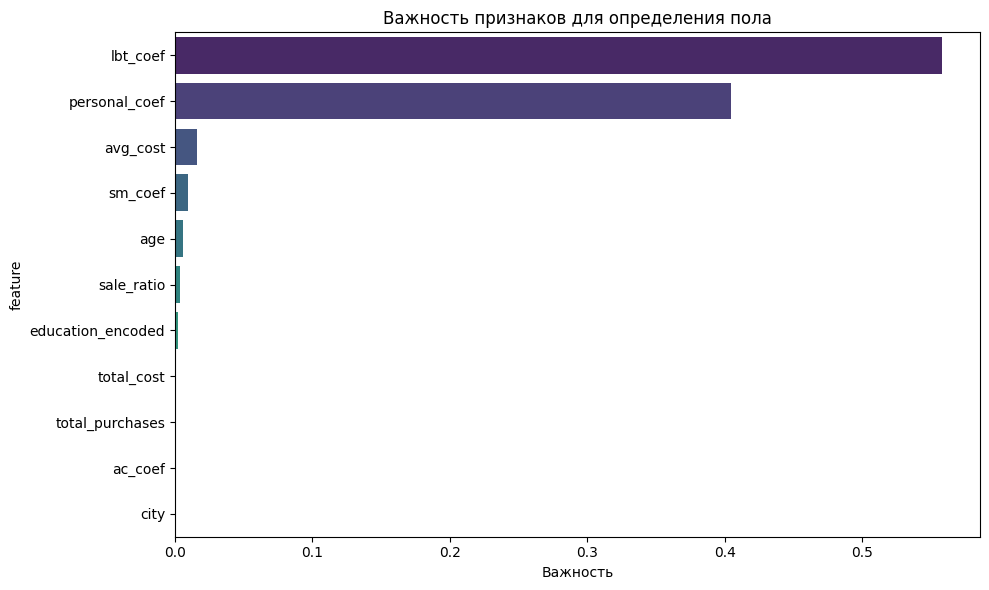


=== 7. Финальное предсказание для утерянных данных ===
Распределение предсказанного пола:
predicted_gender
1    8895
0    6756
Name: count, dtype: int64
Доля класса 0: 43.17%
Доля класса 1: 56.83%

Предсказания сохранены в 'predicted_gender.csv'

=== КЛАССИФИКАЦИЯ УСПЕШНО ЗАВЕРШЕНА ===


In [4]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("=== 1. Кодирование и подготовка признаков ===")
education_map = {'среднее': 0, 'высшее': 1}

unmapped_train = df_train_full.loc[~df_train_full['education'].isin(education_map) &
                                    df_train_full['education'].notna(), 'education'].unique()
unmapped_predict = df_predict_full.loc[~df_predict_full['education'].isin(education_map) &
                                        df_predict_full['education'].notna(), 'education'].unique()
if len(unmapped_train) or len(unmapped_predict):
    print(f"Внимание: встречены категории 'education', не входящие в {list(education_map)}: "
          f"{set(unmapped_train) | set(unmapped_predict)} — кодируем их как -1")

df_train_full['education_encoded'] = df_train_full['education'].map(education_map).fillna(-1)
df_predict_full['education_encoded'] = df_predict_full['education'].map(education_map).fillna(-1)

feature_cols = ['age', 'city',
                'lbt_coef', 'ac_coef', 'sm_coef', 'personal_coef',
                'total_purchases', 'avg_cost', 'total_cost', 'sale_ratio',
                'education_encoded']

X_raw = df_train_full[feature_cols].copy()
y = df_train_full['gender'].copy()
X_predict_raw = df_predict_full[feature_cols].copy()

print("=== 2. Очистка данных ===")
def basic_clean(df):
    df = df.replace([np.inf, -np.inf], np.nan).copy()
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    return df.fillna(0)

X_raw = basic_clean(X_raw)
X_predict_raw = basic_clean(X_predict_raw)

print("=== 3. Разбиение на train/test ===")
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# Важное исправление: границы winsorization рассчитываются ТОЛЬКО на train,
# после чего те же границы применяются к test и к утерянным данным.
clip_cols = ['total_cost', 'avg_cost']
clip_bounds = {}
for col in clip_cols:
    clip_bounds[col] = X_train[col].quantile(0.99)

def apply_clip(df, bounds):
    df = df.copy()
    for col, upper in bounds.items():
        if col in df.columns:
            df[col] = df[col].clip(upper=upper)
    return df

X_train = apply_clip(X_train, clip_bounds)
X_test = apply_clip(X_test, clip_bounds)
X_predict = apply_clip(X_predict_raw, clip_bounds)
X_full = apply_clip(X_raw, clip_bounds)

print("Проверка X на inf и NaN:")
print("Есть inf?", np.isinf(X_train.values).any())
print("Есть NaN?", X_train.isna().any().any())

print("\n=== 4. Обучение базовой модели Random Forest ===")
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
print(f"F1-score (macro): {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"F1-score (weighted): {f1_score(y_test, y_pred, average='weighted'):.4f}")

print("\n=== 5. Подбор гиперпараметров (GridSearchCV) ===")
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [8, 10, 12],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 4]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

print(f"\nЛучшие параметры: {grid_search.best_params_}")
print(f"Лучший F1-score на кросс-валидации: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
print(f"F1-score лучших параметров на тесте: {f1_score(y_test, y_pred_best, average='macro'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))

print("\n=== 6. Важность признаков ===")
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False)
print(feature_importance)

top2_share = feature_importance.head(2)['importance'].sum()
if top2_share > 0.7:
    print(f"\nПРИМЕЧАНИЕ: первые два признака дают {top2_share:.1%} важности. "
          "Это легитимные признаки из personal_data_coeffs; их высокая важность "
          "стоит отдельно прокомментировать в отчёте.")

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature', palette='viridis')
plt.title('Важность признаков для определения пола')
plt.xlabel('Важность')
plt.tight_layout()
plt.show()

print("\n=== 7. Финальное предсказание для утерянных данных ===")
final_model = RandomForestClassifier(**grid_search.best_params_, random_state=42, n_jobs=-1)
final_model.fit(X_full, y)
df_predict_full['predicted_gender'] = final_model.predict(X_predict)

print("Распределение предсказанного пола:")
print(df_predict_full['predicted_gender'].value_counts())
print(f"Доля класса 0: {df_predict_full['predicted_gender'].value_counts(normalize=True).get(0, 0):.2%}")
print(f"Доля класса 1: {df_predict_full['predicted_gender'].value_counts(normalize=True).get(1, 0):.2%}")

result_predictions = df_predict_full[['id', 'predicted_gender']].copy()
result_predictions.to_csv('predicted_gender.csv', index=False)
print("\nПредсказания сохранены в 'predicted_gender.csv'")
print("\n=== КЛАССИФИКАЦИЯ УСПЕШНО ЗАВЕРШЕНА ===")


## 5. Сборка итогового полного датафрейма по клиентам (страна 32)

**Зачем эта ячейка (её не было в исходном ноутбуке).** Один из критериев оценки — «в итоговом датафрейме присутствуют данные по всем покупателям, нет пропусков». В данных по условию задачи два источника клиентов страны 32: таблица `personal_data` в БД (пол известен) и `personal_data.csv.gz` (те же клиенты, но «утерянные» из БД, пол не известен и теперь восстановлен моделью классификации). Без склейки этих двух источников все последующие шаги (кластеризация, модель склонности к покупке для города 1188) видят только часть аудитории страны 32 — тех, кто есть в `personal_data`, — и теряют клиентов, чей профиль лежал в csv. Ниже эти источники объединяются в один полный датафрейм `personal_data_full`, который дальше используется вместо повторных обращений к БД.


In [5]:
print("=== Сборка итогового полного датафрейма по клиентам (страна 32) ===")

# 1) Клиенты из БД — пол известен точно
part_db = personal_data_db.copy()
part_db['data_source'] = 'personal_data (БД)'

# 2) Клиенты из csv — пол восстановлен моделью на предыдущем шаге.
#    ИСПРАВЛЕНО: предсказание подставляется ЧЕРЕЗ MERGE ПО id, а не по
#    позиции (.values). Раньше код полагался на то, что part_csv и
#    df_predict_full построены в одном и том же порядке строк — сейчас это
#    действительно так (оба берут personal_csv_32 без сортировок), но это
#    очень хрупкое допущение: любое изменение порядка строк выше по коду
#    (sort_values, dropna, повторный merge с неуникальным ключом и т.п.)
#    молча перепутает пол клиентов без единой ошибки выполнения. Мёрдж по
#    'id' устраняет этот риск и не зависит от порядка строк.
common_cols = [c for c in personal_data_db.columns if c in personal_csv_32.columns and c != 'gender']
part_csv = personal_csv_32[common_cols].copy()

predicted_gender_map = df_predict_full[['id', 'predicted_gender']].drop_duplicates('id')
part_csv = part_csv.merge(predicted_gender_map, on='id', how='left')

missing_pred = part_csv['predicted_gender'].isna().sum()
if missing_pred:
    raise ValueError(
        f"Для {missing_pred} клиентов из personal_data.csv.gz не нашлось предсказания пола "
        f"(predicted_gender) — проверьте df_predict_full перед сборкой personal_data_full."
    )
part_csv['gender'] = part_csv['predicted_gender'].astype(int)
part_csv = part_csv.drop(columns='predicted_gender')
part_csv['data_source'] = 'personal_data.csv.gz (пол восстановлен моделью)'

# На случай пересечения id между источниками (в норме их быть не должно —
# csv это как раз строки, "утерянные" из БД, — но проверяем явно, чтобы не
# задвоить клиента и не потерять его реальный пол)
overlap_ids = set(part_db['id']) & set(part_csv['id'])
if len(overlap_ids):
    print(f"ВНИМАНИЕ: {len(overlap_ids)} id встречаются и в БД, и в csv — "
          f"оставляем версию из БД (реальный, а не предсказанный пол)")
    part_csv = part_csv[~part_csv['id'].isin(overlap_ids)]

personal_data_full = pd.concat([part_db, part_csv], ignore_index=True, sort=False)

# Присоединяем персональные коэффициенты (personal_coef и др.)
personal_data_full = pd.merge(personal_data_full, coeffs, on='id', how='left')

print(f"personal_data (БД, страна 32): {len(part_db)} клиентов")
print(f"personal_data.csv.gz (страна 32, пол восстановлен): {len(part_csv)} клиентов")
print(f"ИТОГО в personal_data_full: {len(personal_data_full)} клиентов")
print(f"Дубликаты id: {personal_data_full['id'].duplicated().sum()}")
print("\nПропуски в personal_data_full:")
print(personal_data_full.isna().sum())
print("\nРаспределение по источнику данных:")
print(personal_data_full['data_source'].value_counts())

print("\n=== ИТОГОВЫЙ ДАТАФРЕЙМ КЛИЕНТОВ СОБРАН ===")


=== Сборка итогового полного датафрейма по клиентам (страна 32) ===
personal_data (БД, страна 32): 88786 клиентов
personal_data.csv.gz (страна 32, пол восстановлен): 15651 клиентов
ИТОГО в personal_data_full: 104437 клиентов
Дубликаты id: 0

Пропуски в personal_data_full:
id               0
gender           0
age              0
education        0
city             0
country          0
data_source      0
lbt_coef         0
ac_coef          0
sm_coef          0
personal_coef    0
dtype: int64

Распределение по источнику данных:
data_source
personal_data (БД)                                 88786
personal_data.csv.gz (пол восстановлен моделью)    15651
Name: count, dtype: int64

=== ИТОГОВЫЙ ДАТАФРЕЙМ КЛИЕНТОВ СОБРАН ===


## 6. A/B-тест первой маркетинговой кампании


=== 1. Загрузка ID групп для A/B-теста ===
ВНИМАНИЕ: 2 id встречаются в обеих группах — исключаем их из A и B
Positive (страна 32): 2358 клиентов
Negative (страна 32): 2172 клиентов
Покупок во время кампании: 229265

=== 2. Основные A/B-метрики ===
group  assigned_customers  buyers  conversion  revenue_total  revenue_per_customer  purchases_total  purchases_per_customer  avg_order_value
    A                2358    2257      0.9572     65354509.0            27716.0768          12060.0                  5.1145        5826.9012
    B                2172    2171      0.9995     49723003.0            22892.7270           8746.0                  4.0267        6031.3796

=== 3. Статистические тесты ===
Конверсия A: 95.72%; B: 99.95%; relative lift: -4.24%
Fisher exact p-value: 0.000000
Revenue/customer A: 27,716.08; B: 22,892.73; relative lift: +21.07%
Welch t-test p-value for revenue/customer: 0.000263
95% bootstrap CI for difference A-B in revenue/customer: [2,259.86; 7,389.80]
Purchases/cu

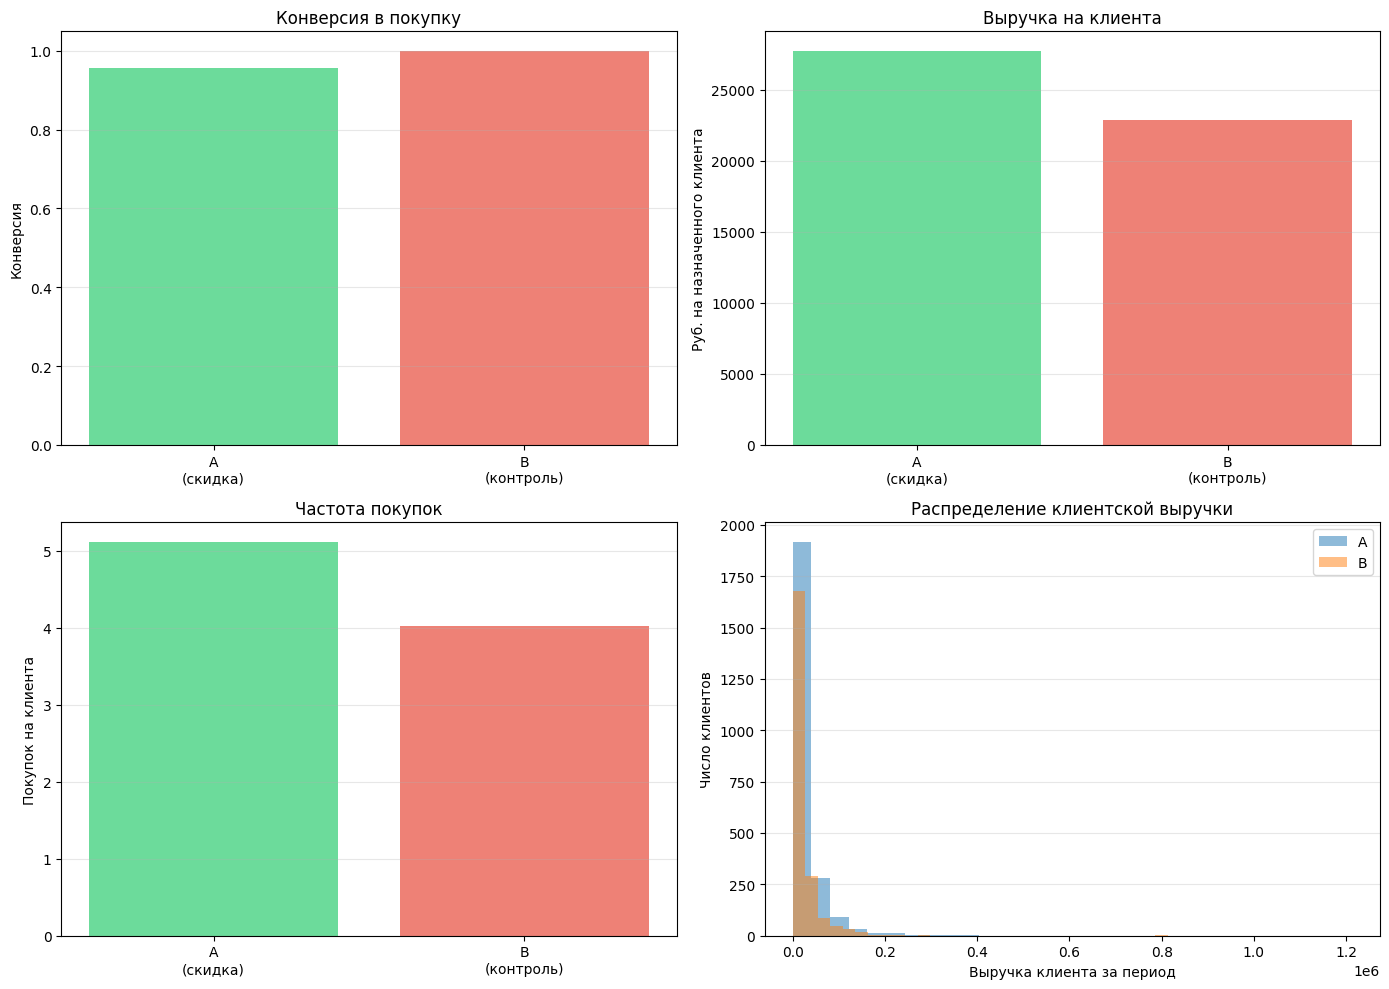


=== 5. ИНТЕРПРЕТАЦИЯ ===
Выручка на одного назначенного клиента: A=27,716 руб., B=22,893 руб.
Наблюдаемый uplift revenue/customer (простая разница уровней): +21.07%
Разница revenue/customer статистически значима по Welch t-test на уровне 5%.
С поправкой на исходные различия групп (DiD): эффект кампании ≈ -114.4 руб./клиента/день.
Конверсия в покупку за период кампании: A=95.7%, B=100.0% — у группы A она ниже, чем у группы B.
При этом выручка на клиента у группы A выше, а конверсия — нет: наблюдаемый прирост выручки объясняется ростом трат уже покупающих клиентов, а не притоком новых покупателей.
Важно: финансовую окупаемость скидки нельзя утверждать без данных о размере скидки и маржинальности.
A/B-метрики сохранены в 'ab_test_summary.csv'


In [6]:
from scipy import stats

print("=== 1. Загрузка ID групп для A/B-теста ===")
with open('ids_first_company_positive.txt', 'r', encoding='utf-8') as f:
    ids_pos = sorted(set(int(x.strip()) for x in f.read().split() if x.strip().isdigit()))
with open('ids_first_company_negative.txt', 'r', encoding='utf-8') as f:
    ids_neg = sorted(set(int(x.strip()) for x in f.read().split() if x.strip().isdigit()))

both = set(ids_pos) & set(ids_neg)
if both:
    print(f"ВНИМАНИЕ: {len(both)} id встречаются в обеих группах — исключаем их из A и B")
    ids_pos = [i for i in ids_pos if i not in both]
    ids_neg = [i for i in ids_neg if i not in both]

country32_ids = set(personal_data_full['id'])
ids_pos = [i for i in ids_pos if i in country32_ids]
ids_neg = [i for i in ids_neg if i in country32_ids]

print(f"Positive (страна 32): {len(ids_pos)} клиентов")
print(f"Negative (страна 32): {len(ids_neg)} клиентов")

purchases = purchases_clean.copy()
purchases['group'] = np.nan
purchases.loc[purchases['id'].isin(ids_pos), 'group'] = 'A'
purchases.loc[purchases['id'].isin(ids_neg), 'group'] = 'B'

campaign_start, campaign_end = 5, 16
purchases_during = purchases[
    (purchases['dt'] >= campaign_start) & (purchases['dt'] <= campaign_end)
].copy()

print(f"Покупок во время кампании: {len(purchases_during)}")

# ВАЖНО: метрики строятся по ВСЕМ назначенным клиентам, а не только по покупателям.
# Поэтому непокупатели получают revenue=0 и purchase_count=0.
ab_population = pd.DataFrame({
    'id': ids_pos + ids_neg,
    'group': ['A'] * len(ids_pos) + ['B'] * len(ids_neg)
}).drop_duplicates('id')

customer_period = (
    purchases_during[purchases_during['group'].isin(['A', 'B'])]
    .groupby('id')
    .agg(
        revenue=('cost', 'sum'),
        purchase_count=('id', 'size'),
        buyer=('id', 'nunique')
    )
    .reset_index()
)
customer_period['buyer'] = 1

ab_customer_metrics = ab_population.merge(customer_period, on='id', how='left')
ab_customer_metrics['revenue'] = ab_customer_metrics['revenue'].fillna(0)
ab_customer_metrics['purchase_count'] = ab_customer_metrics['purchase_count'].fillna(0)
ab_customer_metrics['buyer'] = ab_customer_metrics['buyer'].fillna(0).astype(int)

# Средняя стоимость одной покупки — отдельная метрика только среди покупателей.
ab_customer_metrics['avg_order_value'] = np.where(
    ab_customer_metrics['purchase_count'] > 0,
    ab_customer_metrics['revenue'] / ab_customer_metrics['purchase_count'],
    np.nan
)

summary = ab_customer_metrics.groupby('group').agg(
    assigned_customers=('id', 'count'),
    buyers=('buyer', 'sum'),
    conversion=('buyer', 'mean'),
    revenue_total=('revenue', 'sum'),
    revenue_per_customer=('revenue', 'mean'),
    purchases_total=('purchase_count', 'sum'),
    purchases_per_customer=('purchase_count', 'mean'),
    avg_order_value=('avg_order_value', 'mean')
).reset_index()

print("\n=== 2. Основные A/B-метрики ===")
print(summary.round(4).to_string(index=False))

A = ab_customer_metrics.loc[ab_customer_metrics['group'] == 'A'].copy()
B = ab_customer_metrics.loc[ab_customer_metrics['group'] == 'B'].copy()

conv_a, conv_b = A['buyer'].mean(), B['buyer'].mean()
rev_pc_a, rev_pc_b = A['revenue'].mean(), B['revenue'].mean()
purch_pc_a, purch_pc_b = A['purchase_count'].mean(), B['purchase_count'].mean()

def rel_lift(a, b):
    return (a / b - 1) if b != 0 else np.nan

# При насыщенной конверсии и единичных непокупателях Fisher exact надёжнее
# обычного нормального z-approximation.
contingency = np.array([
    [A['buyer'].sum(), len(A) - A['buyer'].sum()],
    [B['buyer'].sum(), len(B) - B['buyer'].sum()]
])
_, p_value_conv = stats.fisher_exact(contingency)

t_rev, p_value_rev = stats.ttest_ind(A['revenue'], B['revenue'], equal_var=False)
t_purch, p_value_purch = stats.ttest_ind(A['purchase_count'], B['purchase_count'], equal_var=False)

# 95% bootstrap CI для разницы revenue/customer.
rng = np.random.RandomState(42)
boot_diff = []
for _ in range(3000):
    boot_a = rng.choice(A['revenue'].values, size=len(A), replace=True).mean()
    boot_b = rng.choice(B['revenue'].values, size=len(B), replace=True).mean()
    boot_diff.append(boot_a - boot_b)
ci_low, ci_high = np.percentile(boot_diff, [2.5, 97.5])

print("\n=== 3. Статистические тесты ===")
print(f"Конверсия A: {conv_a:.2%}; B: {conv_b:.2%}; relative lift: {rel_lift(conv_a, conv_b):+.2%}")
print(f"Fisher exact p-value: {p_value_conv:.6f}")
print(f"Revenue/customer A: {rev_pc_a:,.2f}; B: {rev_pc_b:,.2f}; relative lift: {rel_lift(rev_pc_a, rev_pc_b):+.2%}")
print(f"Welch t-test p-value for revenue/customer: {p_value_rev:.6f}")
print(f"95% bootstrap CI for difference A-B in revenue/customer: [{ci_low:,.2f}; {ci_high:,.2f}]")
print(f"Purchases/customer A: {purch_pc_a:.3f}; B: {purch_pc_b:.3f}; relative lift: {rel_lift(purch_pc_a, purch_pc_b):+.2%}")
print(f"Welch t-test p-value for purchases/customer: {p_value_purch:.6f}")

# Отдельно показываем AOV среди фактических покупателей, но не используем его
# как основную бизнес-метрику кампании.
print("\nСредний чек только среди покупателей (дополнительная метрика):")
print(summary[['group', 'avg_order_value']].round(2).to_string(index=False))

print("\n=== 4. Проверка баланса групп по допрекламной истории ===")
purchases_before = purchases[purchases['dt'] < campaign_start].copy()
rfm_before_ab = purchases_before.groupby('id').agg(
    frequency_before=('id', 'count'),
    monetary_before=('cost', 'sum')
).reset_index()

balance = ab_population.merge(personal_data_full[['id', 'age']], on='id', how='left').merge(rfm_before_ab, on='id', how='left')
balance[['frequency_before', 'monetary_before']] = balance[['frequency_before', 'monetary_before']].fillna(0)
balance_means = balance.groupby('group')[['age', 'frequency_before', 'monetary_before']].mean()
print(balance_means.round(2))

# ДОБАВЛЕНО: раньше баланс групп проверялся, но результат нигде не
# интерпретировался и не влиял на выводы. Явно считаем относительную разницу
# A vs B ДО начала кампании и предупреждаем, если она существенна.
imbalance_freq = balance_means.loc['A', 'frequency_before'] / balance_means.loc['B', 'frequency_before'] - 1
imbalance_mon = balance_means.loc['A', 'monetary_before'] / balance_means.loc['B', 'monetary_before'] - 1
print(f"\nРазница A vs B ДО кампании: frequency_before {imbalance_freq:+.1%}, monetary_before {imbalance_mon:+.1%}")
if abs(imbalance_freq) > 0.1 or abs(imbalance_mon) > 0.1:
    print("ВНИМАНИЕ: группы A и B заметно различались по покупательской активности ЕЩЁ ДО начала кампании "
          "(>10% относительной разницы). Часть наблюдаемого uplift в выручке может объясняться исходной "
          "разницей между группами, а не эффектом персональной скидки. Поэтому ниже дополнительно считается "
          "difference-in-differences (DiD): прирост выручки на клиента в день внутри каждой группы "
          "(после кампании минус до неё), что частично устраняет влияние исходного дисбаланса.")

# ДОБАВЛЕНО: difference-in-differences — сравниваем ПРИРОСТ revenue/customer/day
# у группы A относительно группы B, а не абсолютный уровень revenue/customer.
# Это устойчивее к тому, что группы изначально были не идеально сбалансированы.
# ИСПРАВЛЕНО: раньше число дней ДО кампании бралось равным campaign_start
# (5), что верно только если нумерация дней в 'dt' начинается с 0. Если в
# данных день считается с 1 (что больше соответствует формулировке ТЗ
# "с 5-го по 16-й день"), то дней ДО кампании на самом деле campaign_start-1,
# и старое значение занижало бы знаменатель на 1 день. Чтобы не гадать,
# считаем число дней ДО кампании прямо по факту диапазона 'dt' в данных.
dt_min = purchases['dt'].min()
pre_period_days = campaign_start - dt_min
if pre_period_days <= 0:
    pre_period_days = 1  # защита от деления на 0/отрицательное число
print(f"\nДиапазон 'dt' в данных: {dt_min}..{purchases['dt'].max()}; "
      f"дней ДО кампании учтено в DiD: {pre_period_days}")
campaign_period_days = campaign_end - campaign_start + 1

rev_before = purchases_before.groupby('id')['cost'].sum().rename('rev_before').reset_index()
rev_before_ab = ab_population.merge(rev_before, on='id', how='left')
rev_before_ab['rev_before_per_day'] = rev_before_ab['rev_before'].fillna(0) / pre_period_days

did_a_before = rev_before_ab.loc[rev_before_ab['group'] == 'A', 'rev_before_per_day'].mean()
did_b_before = rev_before_ab.loc[rev_before_ab['group'] == 'B', 'rev_before_per_day'].mean()
did_a_during = rev_pc_a / campaign_period_days
did_b_during = rev_pc_b / campaign_period_days
did_effect = (did_a_during - did_a_before) - (did_b_during - did_b_before)

print(f"\nDifference-in-differences (руб./клиента/день):")
print(f"  A: было {did_a_before:.1f} -> стало {did_a_during:.1f} (Δ={did_a_during - did_a_before:+.1f})")
print(f"  B: было {did_b_before:.1f} -> стало {did_b_during:.1f} (Δ={did_b_during - did_b_before:+.1f})")
print(f"  DiD-эффект кампании (сверх динамики контрольной группы) ≈ {did_effect:+.1f} руб./клиента/день")

# Графики без неверной подписи "средний чек": основная денежная метрика — revenue/customer.
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0, 0].bar(['A\n(скидка)', 'B\n(контроль)'], [conv_a, conv_b], color=['#2ecc71', '#e74c3c'], alpha=0.7)
axes[0, 0].set_ylabel('Конверсия')
axes[0, 0].set_title('Конверсия в покупку')
axes[0, 0].grid(axis='y', alpha=0.3)

axes[0, 1].bar(['A\n(скидка)', 'B\n(контроль)'], [rev_pc_a, rev_pc_b], color=['#2ecc71', '#e74c3c'], alpha=0.7)
axes[0, 1].set_ylabel('Руб. на назначенного клиента')
axes[0, 1].set_title('Выручка на клиента')
axes[0, 1].grid(axis='y', alpha=0.3)

axes[1, 0].bar(['A\n(скидка)', 'B\n(контроль)'], [purch_pc_a, purch_pc_b], color=['#2ecc71', '#e74c3c'], alpha=0.7)
axes[1, 0].set_ylabel('Покупок на клиента')
axes[1, 0].set_title('Частота покупок')
axes[1, 0].grid(axis='y', alpha=0.3)

axes[1, 1].hist(A['revenue'], bins=30, alpha=0.5, label='A')
axes[1, 1].hist(B['revenue'], bins=30, alpha=0.5, label='B')
axes[1, 1].set_xlabel('Выручка клиента за период')
axes[1, 1].set_ylabel('Число клиентов')
axes[1, 1].set_title('Распределение клиентской выручки')
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n=== 5. ИНТЕРПРЕТАЦИЯ ===")
print(f"Выручка на одного назначенного клиента: A={rev_pc_a:,.0f} руб., B={rev_pc_b:,.0f} руб.")
print(f"Наблюдаемый uplift revenue/customer (простая разница уровней): {rel_lift(rev_pc_a, rev_pc_b):+.2%}")
if p_value_rev < 0.05:
    print("Разница revenue/customer статистически значима по Welch t-test на уровне 5%.")
else:
    print("Разница revenue/customer не достигает уровня статистической значимости 5%.")
# ДОБАВЛЕНО: сводим воедино находки из блока 4 (баланс групп и DiD), а не
# оставляем их как отдельные, не связанные с выводом цифры.
print(f"С поправкой на исходные различия групп (DiD): эффект кампании ≈ {did_effect:+.1f} руб./клиента/день.")
# ИСПРАВЛЕНО: раньше здесь было жёстко зашито "у группы A конверсия НИЖЕ" —
# текст не проверял фактическое соотношение conv_a/conv_b и мог противоречить
# реальным цифрам выше. Теперь вывод строится по факту вычисленных значений.
if conv_a > conv_b:
    conv_direction = "выше, чем"
elif conv_a < conv_b:
    conv_direction = "ниже, чем"
else:
    conv_direction = "на том же уровне, что и"
print(f"Конверсия в покупку за период кампании: A={conv_a:.1%}, B={conv_b:.1%} — "
      f"у группы A она {conv_direction} у группы B.")

if conv_a <= conv_b and rev_pc_a > rev_pc_b:
    print("При этом выручка на клиента у группы A выше, а конверсия — нет: наблюдаемый прирост "
          "выручки объясняется ростом трат уже покупающих клиентов, а не притоком новых покупателей.")
elif conv_a > conv_b and rev_pc_a > rev_pc_b:
    print("У группы A выше и конверсия, и выручка на клиента: кампания одновременно привлекает "
          "новых покупателей и увеличивает их траты.")
elif rev_pc_a <= rev_pc_b:
    print("Выручка на клиента в группе A не превышает контрольную группу B — по имеющимся данным "
          "персональная скидка не привела к приросту выручки на назначенного клиента.")
print("Важно: финансовую окупаемость скидки нельзя утверждать без данных о размере скидки и маржинальности.")

ab_test_summary = summary.copy()
ab_test_summary['revenue_lift_vs_B'] = ab_test_summary['revenue_per_customer'] / rev_pc_b - 1
ab_test_summary.to_csv('ab_test_summary.csv', index=False)
print("A/B-метрики сохранены в 'ab_test_summary.csv'")


## 7. Анализ второй маркетинговой кампании (город 1134)

Для второй кампании нет отдельной рандомизированной контрольной группы: акция действовала для всех жителей города 1134 в дни 15 и 45. Поэтому ниже используется локальное сравнение этих дней с соседними днями (14, 16, 44, 46). Это **наблюдательный анализ**, а не полноценный A/B-тест, поэтому результаты интерпретируются как ассоциации с акционными днями, а не как строго причинный эффект.

**Важная оговорка.** Первая кампания шла с 5-го по 16-й день, поэтому дни 14 и 16 из «соседних» дней сами попадают в её окно и не являются чистым контролем: часть жителей города 1134 могла получить персональную скидку по первой кампании именно в эти дни, что может завышать базовый уровень в соседних днях. День 45 (второе повторение акции 15-го числа) и его соседи 44/46 таким пересечением не затронуты. Поэтому ниже, помимо основной оценки по всем 6 дням, отдельно считается «чистая» оценка только по дням 44/45/46.


=== ВТОРАЯ КАМПАНИЯ: ГОРОД 1134, ДНИ 15 И 45 ===
Клиентов в городе 1134: 26809

Средние показатели на клиента в день:
         Метрика  Акционные дни 15/45  Соседние дни
         Выручка            1175.2070      857.8677
Доля покупателей               0.1135        0.0939
         Покупок               0.2026        0.1546
Выручка/день: разница=317.339242, Wilcoxon p-value=0.782422
Конверсия/день: разница=0.019536, Wilcoxon p-value=0.000000
Покупок/день: разница=0.047978, Wilcoxon p-value=0.000000

=== 4. Робастность: проверка ТОЛЬКО по дню 45 (без пересечения с первой кампанией) ===
Выручка/день (только день 45 vs 44/46): разница=280.846805, Wilcoxon p-value=0.856648
Конверсия/день (только день 45 vs 44/46): разница=0.013522, Wilcoxon p-value=0.000000
Покупок/день (только день 45 vs 44/46): разница=0.034018, Wilcoxon p-value=0.000000
Если знаки/значимость этой 'чистой' проверки совпадают с основной оценкой по всем 6 дням — пересечение с первой кампанией, скорее всего, не исказило выв

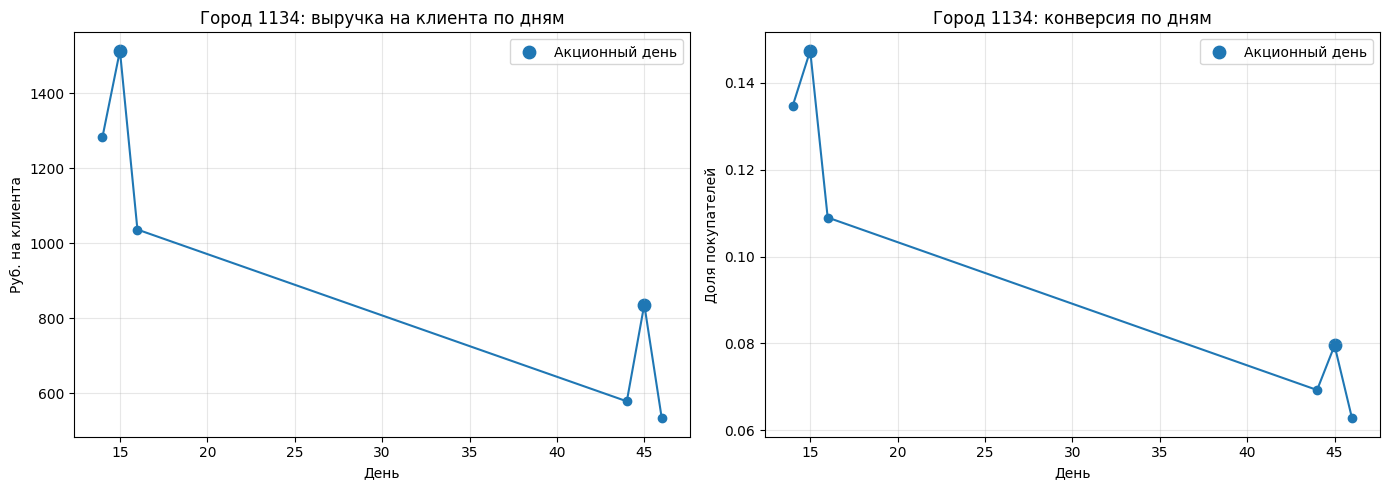

Результаты второй кампании сохранены в CSV.


In [7]:
print("=== ВТОРАЯ КАМПАНИЯ: ГОРОД 1134, ДНИ 15 И 45 ===")
city2 = 1134
promo_days = [15, 45]
neighbor_days = [14, 16, 44, 46]

city2_ids = personal_data_full.loc[personal_data_full['city'] == city2, 'id'].dropna().astype(int).unique()
print(f"Клиентов в городе {city2}: {len(city2_ids)}")

p_city2 = purchases_clean[purchases_clean['id'].isin(city2_ids)].copy()

# Полный daily panel на уровне клиентов только для выбранных event/control days.
selected_days = promo_days + neighbor_days
panel = pd.MultiIndex.from_product(
    [city2_ids, selected_days], names=['id', 'dt']
).to_frame(index=False)

purchase_day = (
    p_city2[p_city2['dt'].isin(selected_days)]
    .groupby(['id', 'dt'])
    .agg(
        revenue=('cost', 'sum'),
        purchase_count=('id', 'size')
    )
    .reset_index()
)
purchase_day['buyer'] = 1
panel = panel.merge(purchase_day, on=['id', 'dt'], how='left')
panel[['revenue', 'purchase_count', 'buyer']] = panel[['revenue', 'purchase_count', 'buyer']].fillna(0)
panel['is_promo_day'] = panel['dt'].isin(promo_days).astype(int)

# Сравниваем одного и того же клиента: среднее за 2 акционные даты vs
# среднее за 4 соседних даты. Это уменьшает влияние постоянных различий между людьми.
event_person = panel[panel['is_promo_day'] == 1].groupby('id').agg(
    revenue_per_day_event=('revenue', 'mean'),
    buyer_rate_event=('buyer', 'mean'),
    purchases_per_day_event=('purchase_count', 'mean')
)
control_person = panel[panel['is_promo_day'] == 0].groupby('id').agg(
    revenue_per_day_neighbor=('revenue', 'mean'),
    buyer_rate_neighbor=('buyer', 'mean'),
    purchases_per_day_neighbor=('purchase_count', 'mean')
)

campaign2_person = event_person.join(control_person, how='inner').reset_index()

for base, event_col, ctrl_col in [
    ('revenue', 'revenue_per_day_event', 'revenue_per_day_neighbor'),
    ('buyer_rate', 'buyer_rate_event', 'buyer_rate_neighbor'),
    ('purchases', 'purchases_per_day_event', 'purchases_per_day_neighbor')
]:
    campaign2_person[f'{base}_diff'] = campaign2_person[event_col] - campaign2_person[ctrl_col]

print("\nСредние показатели на клиента в день:")
print(pd.DataFrame({
    'Метрика': ['Выручка', 'Доля покупателей', 'Покупок'],
    'Акционные дни 15/45': [
        campaign2_person['revenue_per_day_event'].mean(),
        campaign2_person['buyer_rate_event'].mean(),
        campaign2_person['purchases_per_day_event'].mean()
    ],
    'Соседние дни': [
        campaign2_person['revenue_per_day_neighbor'].mean(),
        campaign2_person['buyer_rate_neighbor'].mean(),
        campaign2_person['purchases_per_day_neighbor'].mean()
    ]
}).round(4).to_string(index=False))

# Парные Wilcoxon-тесты: один и тот же клиент сравнивается с самим собой.
for metric, event_col, ctrl_col in [
    ('Выручка/день', 'revenue_per_day_event', 'revenue_per_day_neighbor'),
    ('Конверсия/день', 'buyer_rate_event', 'buyer_rate_neighbor'),
    ('Покупок/день', 'purchases_per_day_event', 'purchases_per_day_neighbor')
]:
    diff = campaign2_person[event_col] - campaign2_person[ctrl_col]
    if np.allclose(diff, 0):
        pval = 1.0
    else:
        try:
            pval = stats.wilcoxon(campaign2_person[event_col], campaign2_person[ctrl_col], zero_method='wilcox').pvalue
        except ValueError:
            pval = np.nan
    print(f"{metric}: разница={diff.mean():.6f}, Wilcoxon p-value={pval:.6f}")

# ДОБАВЛЕНО: "чистая" проверка без пересечения с первой кампанией.
# Дни 14 и 16 входят в окно первой кампании (5–16 день), поэтому основная
# оценка выше (по всем 6 дням) может быть смещена, если часть жителей
# города 1134 получила персональную скидку по первой кампании именно в эти
# дни. День 45 и его соседи 44/46 этим не затронуты, поэтому пересчитываем
# тот же парный тест только на этой "чистой" паре дат.
print("\n=== 4. Робастность: проверка ТОЛЬКО по дню 45 (без пересечения с первой кампанией) ===")
clean_promo_days = [45]
clean_neighbor_days = [44, 46]

event_person_clean = panel[panel['dt'].isin(clean_promo_days)].groupby('id').agg(
    revenue_per_day_event=('revenue', 'mean'),
    buyer_rate_event=('buyer', 'mean'),
    purchases_per_day_event=('purchase_count', 'mean')
)
control_person_clean = panel[panel['dt'].isin(clean_neighbor_days)].groupby('id').agg(
    revenue_per_day_neighbor=('revenue', 'mean'),
    buyer_rate_neighbor=('buyer', 'mean'),
    purchases_per_day_neighbor=('purchase_count', 'mean')
)
campaign2_person_clean = event_person_clean.join(control_person_clean, how='inner').reset_index()

for metric, event_col, ctrl_col in [
    ('Выручка/день', 'revenue_per_day_event', 'revenue_per_day_neighbor'),
    ('Конверсия/день', 'buyer_rate_event', 'buyer_rate_neighbor'),
    ('Покупок/день', 'purchases_per_day_event', 'purchases_per_day_neighbor')
]:
    diff_clean = campaign2_person_clean[event_col] - campaign2_person_clean[ctrl_col]
    if np.allclose(diff_clean, 0):
        pval_clean = 1.0
    else:
        try:
            pval_clean = stats.wilcoxon(
                campaign2_person_clean[event_col], campaign2_person_clean[ctrl_col], zero_method='wilcox'
            ).pvalue
        except ValueError:
            pval_clean = np.nan
    print(f"{metric} (только день 45 vs 44/46): разница={diff_clean.mean():.6f}, Wilcoxon p-value={pval_clean:.6f}")

print("Если знаки/значимость этой 'чистой' проверки совпадают с основной оценкой по всем 6 дням — "
      "пересечение с первой кампанией, скорее всего, не исказило вывод; если расходятся — в отчёте "
      "стоит опираться на эту 'чистую' оценку.")

# Вспомогательная таблица по каждому дню для графика и отчёта.
daily_city2 = panel.groupby('dt').agg(
    revenue=('revenue', 'sum'),
    buyers=('buyer', 'sum'),
    purchases=('purchase_count', 'sum')
).reset_index()
daily_city2['revenue_per_customer'] = daily_city2['revenue'] / len(city2_ids)
daily_city2['conversion'] = daily_city2['buyers'] / len(city2_ids)
daily_city2['is_promo_day'] = daily_city2['dt'].isin(promo_days)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(daily_city2['dt'], daily_city2['revenue_per_customer'], marker='o')
axes[0].scatter(
    daily_city2.loc[daily_city2['is_promo_day'], 'dt'],
    daily_city2.loc[daily_city2['is_promo_day'], 'revenue_per_customer'],
    s=80, label='Акционный день'
)
axes[0].set_title('Город 1134: выручка на клиента по дням')
axes[0].set_xlabel('День')
axes[0].set_ylabel('Руб. на клиента')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(daily_city2['dt'], daily_city2['conversion'], marker='o')
axes[1].scatter(
    daily_city2.loc[daily_city2['is_promo_day'], 'dt'],
    daily_city2.loc[daily_city2['is_promo_day'], 'conversion'],
    s=80, label='Акционный день'
)
axes[1].set_title('Город 1134: конверсия по дням')
axes[1].set_xlabel('День')
axes[1].set_ylabel('Доля покупателей')
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

daily_city2.to_csv('city_1134_campaign2_daily.csv', index=False)
campaign2_person.to_csv('city_1134_campaign2_customer_level.csv', index=False)
print("Результаты второй кампании сохранены в CSV.")


## 8. Кластеризация аудитории (K-Means)

Кластеризация выполнена по полному списку клиентов страны 32. Для устойчивости к скошенным RFM-признакам перед StandardScaler применяются log1p-преобразования. Число кластеров выбирается по Silhouette среди k=3..8; исходное разбиение k=2 не используется, поскольку оно слишком грубо для бизнес-сегментации.


=== 1. Подготовка данных для кластеризации ===
Итоговый датасет для кластеризации: (104437, 18)
Пропусков:
age                0
frequency          0
monetary           0
avg_cost           0
sale_ratio         0
recency            0
unique_products    0
has_purchase       0
dtype: int64

=== 2. Формирование признаков ===
Признаки: ['age', 'frequency', 'monetary', 'avg_cost', 'sale_ratio', 'recency', 'unique_products', 'has_purchase']

=== 3. Выбор числа кластеров ===
k=3: inertia=452999.31, silhouette=0.178, DB=1.675, CH=27274.11, min cluster=30.9%, max cluster=38.0%
k=4: inertia=408188.52, silhouette=0.173, DB=1.644, CH=23837.82, min cluster=21.9%, max cluster=26.6%
k=5: inertia=373607.75, silhouette=0.165, DB=1.618, CH=21846.83, min cluster=14.9%, max cluster=27.9%
k=6: inertia=346139.12, silhouette=0.169, DB=1.581, CH=20451.33, min cluster=12.2%, max cluster=22.1%
k=7: inertia=324102.06, silhouette=0.167, DB=1.469, CH=19334.54, min cluster=12.2%, max cluster=17.9%
k=8: inertia=30733

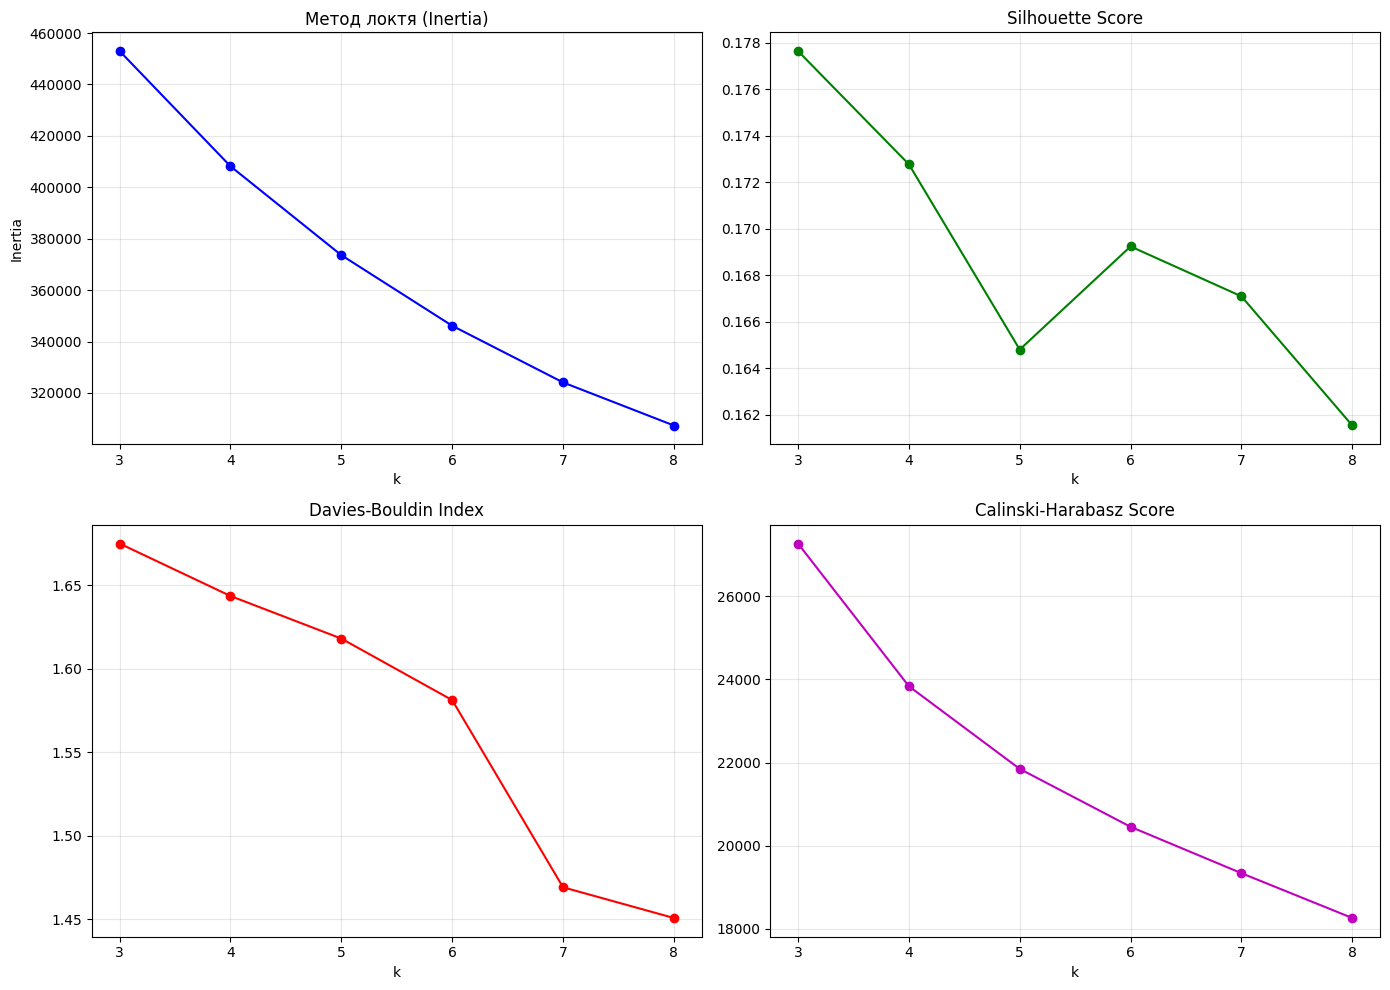


=== ОПТИМАЛЬНОЕ КОЛИЧЕСТВО КЛАСТЕРОВ: 3 ===
Silhouette: 0.178
Davies-Bouldin: 1.675
Calinski-Harabasz: 27274.11
Примечание: k=2 не использовался, поскольку он даёт слишком грубое 'основная масса vs экстремально активные' разбиение и хуже отвечает задаче actionable-сегментации.

=== 4. Финальная кластеризация ===
cluster
0    39684
1    32343
2    32410
Name: count, dtype: int64
cluster
0    38.00
1    30.97
2    31.03
Name: count, dtype: float64

=== 5. Профили кластеров ===
           age  frequency  monetary  avg_cost  sale_ratio  recency  \
cluster                                                              
0        38.35       3.58   9471.78   2865.98        0.38    21.24   
1        36.43       4.51  44967.98  10721.23        0.19    20.46   
2        39.23      15.18  73807.13   4748.82        0.40     9.01   

         unique_products  has_purchase  
cluster                                 
0                   3.30           1.0  
1                   4.14           1.0  
2   

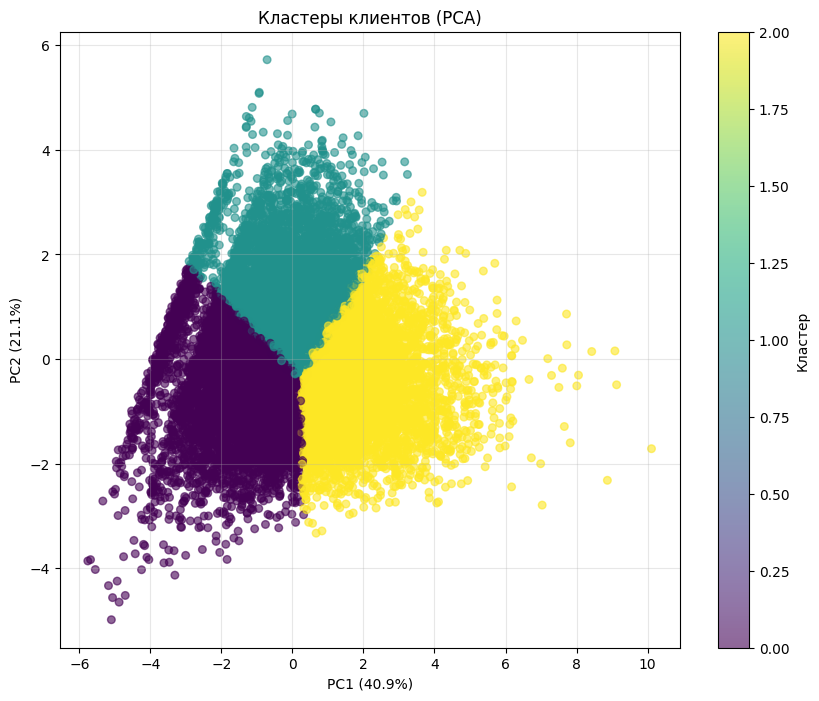

Суммарная объяснённая дисперсия PCA: 0.6197028162328969

=== 7. Предпочтения по товарам ===

Кластер 0 — топ-5 товаров:
 cluster                product  purchase_count
     0.0    Шорты Мужские Demix            1202
     0.0    Брюки Мужские Demix            1143
     0.0       Лиф Женский Joss            1016
     0.0 Футболка Мужская Demix             981
     0.0 Купальник Женский Joss             895

Кластер 1 — топ-5 товаров:
 cluster                           product  purchase_count
     1.0               Сабо Crocs Crocband             661
     1.0               Брюки Мужские Demix             554
     1.0          Брюки Мужские Outventure             528
     1.0               Шорты Мужские Demix             528
     1.0 Кроссовки Мужские New Balance 574             417

Кластер 2 — топ-5 товаров:
 cluster                product  purchase_count
     2.0    Брюки Мужские Demix            3222
     2.0    Шорты Мужские Demix            2881
     2.0 Футболка Мужская Demix       

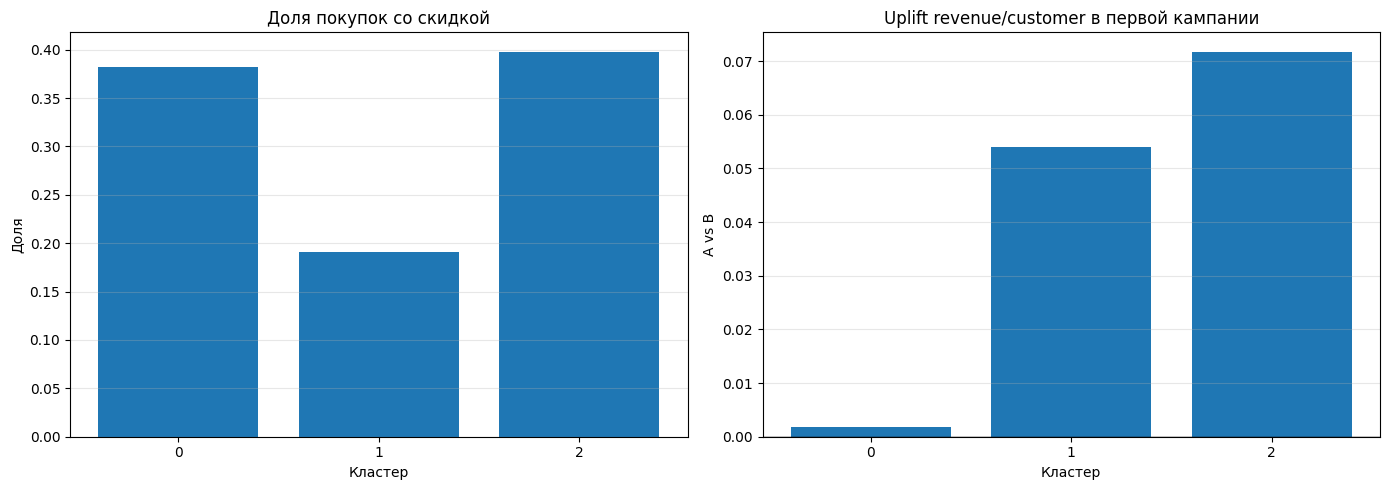


=== 9. БИЗНЕС-РЕКОМЕНДАЦИИ ПО КЛАСТЕРАМ ===

Кластер 0: Стабильные клиенты
Размер: 39684 (38.0%)
Frequency=3.58, Monetary=9472, Sale ratio=38.19%, Recency=21.24
Топ-товар: Шорты Мужские Demix
Рекомендация: Кросс-селлинг, бонусные механики и персональные рекомендации.

Кластер 1: Редкие, но дорогие покупки
Размер: 32343 (31.0%)
Frequency=4.51, Monetary=44968, Sale ratio=19.14%, Recency=20.46
Топ-товар: Сабо Crocs Crocband
Рекомендация: Увеличивать частоту контактов и кросс-селлинг дорогих/смежных товаров.

Кластер 2: VIP / high value
Размер: 32410 (31.0%)
Frequency=15.18, Monetary=73807, Sale ratio=39.80%, Recency=9.01
Топ-товар: Брюки Мужские Demix
Рекомендация: Лояльность, ранний доступ и сервис; скидка не должна быть единственной мотивацией.

Результаты кластеризации сохранены в CSV.

=== КЛАСТЕРИЗАЦИЯ ЗАВЕРШЕНА ===


In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA

print("=== 1. Подготовка данных для кластеризации ===")
personal_data = personal_data_full.copy()
purchases = purchases_clean.copy()

# RFM по всему доступному периоду.
max_day_all = purchases['dt'].max()
rfm = purchases.groupby('id').agg(
    last_purchase_day=('dt', 'max'),
    frequency=('id', 'count'),
    monetary=('cost', 'sum'),
    avg_cost=('cost', 'mean'),
    sale_ratio=('base_sale', 'mean'),
    unique_products=('product', 'nunique')
).reset_index()
rfm['recency'] = max_day_all - rfm['last_purchase_day']
rfm = rfm.drop(columns='last_purchase_day')
rfm['has_purchase'] = 1

# Для клиентов без покупок recency НЕ равен 0: это принципиально важно.
df_cluster = pd.merge(personal_data, rfm, on='id', how='left')
df_cluster['has_purchase'] = df_cluster['has_purchase'].fillna(0).astype(int)
df_cluster['recency'] = df_cluster['recency'].fillna(max_day_all + 1)
for col in ['frequency', 'monetary', 'avg_cost', 'sale_ratio', 'unique_products']:
    df_cluster[col] = df_cluster[col].fillna(0)

print(f"Итоговый датасет для кластеризации: {df_cluster.shape}")
print("Пропусков:")
print(df_cluster[['age', 'frequency', 'monetary', 'avg_cost', 'sale_ratio', 'recency', 'unique_products', 'has_purchase']].isna().sum())

print("\n=== 2. Формирование признаков ===")
# Денежные и частотные признаки сильно скошены, поэтому логарифмируем их
# перед StandardScaler. Профили ниже всё равно выводятся в исходных единицах.
cluster_features = ['age', 'frequency', 'monetary', 'avg_cost', 'sale_ratio', 'recency', 'unique_products', 'has_purchase']
X_cluster_model = df_cluster[cluster_features].copy()
for col in ['frequency', 'monetary', 'avg_cost', 'recency', 'unique_products']:
    X_cluster_model[col] = np.log1p(X_cluster_model[col])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster_model)
print("Признаки:", cluster_features)

print("\n=== 3. Выбор числа кластеров ===")
MAX_ROWS_FOR_SEARCH = 100_000
if len(X_scaled) > MAX_ROWS_FOR_SEARCH:
    rng = np.random.RandomState(42)
    sample_idx = rng.choice(len(X_scaled), size=MAX_ROWS_FOR_SEARCH, replace=False)
    X_scaled_search = X_scaled[sample_idx]
else:
    X_scaled_search = X_scaled

# k=2 сознательно не рассматриваем: для бизнес-сегментации заказчик просит
# несколько самостоятельных аудиторий и отдельные методы работы с ними.
k_range = range(3, 9)
inertia, silhouette_scores, davies_bouldin_scores, calinski_harabasz_scores = [], [], [], []
max_cluster_share, min_cluster_share = [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels = km.fit_predict(X_scaled_search)
    inertia.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled_search, labels))
    davies_bouldin_scores.append(davies_bouldin_score(X_scaled_search, labels))
    calinski_harabasz_scores.append(calinski_harabasz_score(X_scaled_search, labels))
    shares = pd.Series(labels).value_counts(normalize=True)
    max_cluster_share.append(shares.max())
    min_cluster_share.append(shares.min())
    print(f"k={k}: inertia={km.inertia_:.2f}, silhouette={silhouette_scores[-1]:.3f}, "
          f"DB={davies_bouldin_scores[-1]:.3f}, CH={calinski_harabasz_scores[-1]:.2f}, "
          f"min cluster={shares.min():.1%}, max cluster={shares.max():.1%}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0,0].plot(list(k_range), inertia, 'bo-'); axes[0,0].set_title('Метод локтя (Inertia)'); axes[0,0].set_xlabel('k'); axes[0,0].set_ylabel('Inertia'); axes[0,0].grid(alpha=0.3)
axes[0,1].plot(list(k_range), silhouette_scores, 'go-'); axes[0,1].set_title('Silhouette Score'); axes[0,1].set_xlabel('k'); axes[0,1].grid(alpha=0.3)
axes[1,0].plot(list(k_range), davies_bouldin_scores, 'ro-'); axes[1,0].set_title('Davies-Bouldin Index'); axes[1,0].set_xlabel('k'); axes[1,0].grid(alpha=0.3)
axes[1,1].plot(list(k_range), calinski_harabasz_scores, 'mo-'); axes[1,1].set_title('Calinski-Harabasz Score'); axes[1,1].set_xlabel('k'); axes[1,1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Среди k>=3 выбираем максимум silhouette. Дополнительные метрики и размеры
# кластеров печатаются для прозрачного обоснования выбора.
k_list = list(k_range)
optimal_k = k_list[int(np.argmax(silhouette_scores))]
print(f"\n=== ОПТИМАЛЬНОЕ КОЛИЧЕСТВО КЛАСТЕРОВ: {optimal_k} ===")
print(f"Silhouette: {silhouette_scores[k_list.index(optimal_k)]:.3f}")
print(f"Davies-Bouldin: {davies_bouldin_scores[k_list.index(optimal_k)]:.3f}")
print(f"Calinski-Harabasz: {calinski_harabasz_scores[k_list.index(optimal_k)]:.2f}")
print("Примечание: k=2 не использовался, поскольку он даёт слишком грубое 'основная масса vs экстремально активные' разбиение и хуже отвечает задаче actionable-сегментации.")

print("\n=== 4. Финальная кластеризация ===")
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10, max_iter=300)
kmeans_final.fit(X_scaled_search)
df_cluster['cluster'] = kmeans_final.predict(X_scaled)

cluster_counts = df_cluster['cluster'].value_counts().sort_index()
print(cluster_counts)
print((cluster_counts / len(df_cluster) * 100).round(2))

print("\n=== 5. Профили кластеров ===")
profile_cols = ['age', 'frequency', 'monetary', 'avg_cost', 'sale_ratio', 'recency', 'unique_products', 'has_purchase']
cluster_profiles = df_cluster.groupby('cluster')[profile_cols].mean()
print(cluster_profiles.round(2))

for feat in ['gender', 'education']:
    if feat in df_cluster.columns:
        print(f"\nРаспределение {feat} по кластерам:")
        print(df_cluster.groupby('cluster')[feat].value_counts(normalize=True).unstack().round(3))

print("\n=== 6. PCA-визуализация ===")
pca = PCA(n_components=2, random_state=42)
pca.fit(X_scaled_search)
X_pca = pca.transform(X_scaled)
plot_size = min(20_000, len(X_pca))
plot_idx = np.random.RandomState(42).choice(len(X_pca), size=plot_size, replace=False)
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[plot_idx,0], X_pca[plot_idx,1], c=df_cluster['cluster'].values[plot_idx], cmap='viridis', alpha=0.6, s=30)
plt.colorbar(scatter, label='Кластер')
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
plt.title('Кластеры клиентов (PCA)')
plt.grid(alpha=0.3)
plt.show()
print("Суммарная объяснённая дисперсия PCA:", pca.explained_variance_ratio_.sum())

print("\n=== 7. Предпочтения по товарам ===")
purchases_with_clusters = pd.merge(purchases, df_cluster[['id', 'cluster']], on='id', how='left')
if 'product' in purchases_with_clusters.columns:
    top_products_per_cluster = (
        purchases_with_clusters.dropna(subset=['cluster'])
        .groupby(['cluster', 'product'])
        .size().reset_index(name='purchase_count')
        .sort_values(['cluster', 'purchase_count'], ascending=[True, False])
    )
    for cluster_id in sorted(top_products_per_cluster['cluster'].unique()):
        print(f"\nКластер {int(cluster_id)} — топ-5 товаров:")
        print(top_products_per_cluster[top_products_per_cluster['cluster'] == cluster_id].head(5).to_string(index=False))

print("\n=== 8. Скидка: описательная метрика + A/B-эффект по кластерам ===")
# Простая доля покупок со скидкой — ассоциация, а не причинный эффект.
sale_impact = df_cluster.groupby('cluster').agg(
    avg_sale_ratio=('sale_ratio', 'mean'),
    total_revenue=('monetary', 'sum'),
    avg_frequency=('frequency', 'mean')
).round(3)
print("Доля покупок со скидкой по кластерам (ассоциация):")
print(sale_impact)

# Более содержательная оценка влияния первой кампании: revenue/customer в A и B
# внутри каждого кластера. Важно: кластеры построены по всему периоду, поэтому
# это subgroup-analysis, а не идеально чистый causal estimator.
cluster_ab = ab_customer_metrics.merge(df_cluster[['id', 'cluster']], on='id', how='inner')
cluster_ab_summary = cluster_ab.groupby(['cluster', 'group']).agg(
    customers=('id', 'count'),
    conversion=('buyer', 'mean'),
    revenue_per_customer=('revenue', 'mean'),
    purchases_per_customer=('purchase_count', 'mean')
).reset_index()
print("\nA/B-метрики по кластерам:")
print(cluster_ab_summary.round(4).to_string(index=False))

cluster_effect_rows = []
for cluster_id in sorted(cluster_ab['cluster'].dropna().unique()):
    a = cluster_ab[(cluster_ab['cluster'] == cluster_id) & (cluster_ab['group'] == 'A')]['revenue']
    b = cluster_ab[(cluster_ab['cluster'] == cluster_id) & (cluster_ab['group'] == 'B')]['revenue']
    if len(a) > 1 and len(b) > 1:
        pval = stats.ttest_ind(a, b, equal_var=False).pvalue
    else:
        pval = np.nan
    cluster_effect_rows.append({
        'cluster': int(cluster_id),
        'revenue_per_customer_A': a.mean() if len(a) else np.nan,
        'revenue_per_customer_B': b.mean() if len(b) else np.nan,
        'revenue_lift_A_vs_B': (a.mean()/b.mean()-1) if len(b) and b.mean() != 0 else np.nan,
        'p_value_revenue': pval,
        'n_A': len(a), 'n_B': len(b)
    })
cluster_discount_effect = pd.DataFrame(cluster_effect_rows)
print("\nЭффект первой кампании по кластерам:")
print(cluster_discount_effect.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(sale_impact.index.astype(str), sale_impact['avg_sale_ratio'])
axes[0].set_title('Доля покупок со скидкой')
axes[0].set_xlabel('Кластер'); axes[0].set_ylabel('Доля'); axes[0].grid(axis='y', alpha=0.3)
plot_effect = cluster_discount_effect.set_index('cluster')
axes[1].bar(plot_effect.index.astype(str), plot_effect['revenue_lift_A_vs_B'])
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('Uplift revenue/customer в первой кампании')
axes[1].set_xlabel('Кластер'); axes[1].set_ylabel('A vs B'); axes[1].grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

print("\n=== 9. БИЗНЕС-РЕКОМЕНДАЦИИ ПО КЛАСТЕРАМ ===")
active_clients = df_cluster[df_cluster['frequency'] > 0]
freq_q25, freq_q50, freq_q75 = active_clients['frequency'].quantile([.25,.5,.75])
mon_q25, mon_q50, mon_q75 = active_clients['monetary'].quantile([.25,.5,.75])
cluster_top_product = {}
cluster_recommendations = []

for cluster_id in sorted(df_cluster['cluster'].unique()):
    cluster_data = df_cluster[df_cluster['cluster'] == cluster_id]
    profile = cluster_profiles.loc[cluster_id]
    top1 = top_products_per_cluster[top_products_per_cluster['cluster'] == cluster_id].head(1) if 'product' in purchases_with_clusters.columns else pd.DataFrame()
    top_product = top1['product'].iloc[0] if len(top1) else np.nan
    if pd.notna(top_product):
        cluster_top_product[int(cluster_id)] = top_product

    freq, mon, sale = profile['frequency'], profile['monetary'], profile['sale_ratio']
    if freq < freq_q25 and mon < mon_q25:
        cluster_type = 'Низкоактивные / реактивация'
        recommendation = 'Реактивация, недорогие персональные стимулы, подборки популярных товаров.'
    elif freq >= freq_q75 and mon >= mon_q75:
        cluster_type = 'VIP / high value'
        recommendation = 'Лояльность, ранний доступ и сервис; скидка не должна быть единственной мотивацией.'
    elif sale > 0.5:
        cluster_type = 'Скидочно-чувствительные'
        recommendation = 'Персональные акции и bundles с контролем маржинальности.'
    elif freq < freq_q50 and mon >= mon_q75:
        cluster_type = 'Редкие, но дорогие покупки'
        recommendation = 'Увеличивать частоту контактов и кросс-селлинг дорогих/смежных товаров.'
    else:
        cluster_type = 'Стабильные клиенты'
        recommendation = 'Кросс-селлинг, бонусные механики и персональные рекомендации.'

    cluster_recommendations.append({
        'cluster': int(cluster_id),
        'size': len(cluster_data),
        'share': len(cluster_data)/len(df_cluster),
        'cluster_type': cluster_type,
        'top_product': top_product,
        'recommendation': recommendation
    })
    print(f"\nКластер {int(cluster_id)}: {cluster_type}")
    print(f"Размер: {len(cluster_data)} ({len(cluster_data)/len(df_cluster):.1%})")
    print(f"Frequency={freq:.2f}, Monetary={mon:.0f}, Sale ratio={sale:.2%}, Recency={profile['recency']:.2f}")
    print(f"Топ-товар: {top_product}")
    print(f"Рекомендация: {recommendation}")

cluster_recommendations = pd.DataFrame(cluster_recommendations)
cluster_profiles.to_csv('cluster_profiles.csv')
cluster_discount_effect.to_csv('cluster_discount_effects.csv', index=False)
cluster_recommendations.to_csv('cluster_recommendations.csv', index=False)
print("\nРезультаты кластеризации сохранены в CSV.")
print("\n=== КЛАСТЕРИЗАЦИЯ ЗАВЕРШЕНА ===")


## 9. Модель склонности к покупке конкретного товара для города 1188

Модель построена на уровне **клиент × товар**. Целевой признак равен 1, если клиент купил именно данный товар в период первой кампании. Используются две модели T-learner: отдельно для клиентов с предложением и без предложения; на целевой аудитории города 1188 сравниваются две вероятности и рассчитывается model uplift.


In [9]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.utils.class_weight import compute_sample_weight

print("=== МОДЕЛЬ СКЛОННОСТИ К ПОКУПКЕ КОНКРЕТНОГО ТОВАРА: T-LEARNER ===")
print("Обучение проводится на customer × product уровне по данным первой кампании.")

# -------------------------------------------------------------------------
# 1. История до кампании: только информация dt < 5, без утечки будущего.
# -------------------------------------------------------------------------
purchases = purchases_clean.copy()
campaign_start, campaign_end = 5, 16
pre = purchases[purchases['dt'] < campaign_start].copy()
campaign = purchases[(purchases['dt'] >= campaign_start) & (purchases['dt'] <= campaign_end)].copy()

campaign_population = pd.DataFrame({
    'id': ids_pos + ids_neg,
    'received_personal_offer': [1] * len(ids_pos) + [0] * len(ids_neg)
}).drop_duplicates('id')

model_population = campaign_population.merge(personal_data_full, on='id', how='inner')

rfm_before = pre.groupby('id').agg(
    frequency_before=('id', 'count'),
    monetary_before=('cost', 'sum'),
    avg_cost_before=('cost', 'mean'),
    sale_ratio_before=('base_sale', 'mean'),
    unique_products_before=('product', 'nunique'),
    last_purchase_day_before=('dt', 'max')
).reset_index()
rfm_before['recency_before'] = campaign_start - rfm_before['last_purchase_day_before']
rfm_before = rfm_before.drop(columns='last_purchase_day_before')
model_population = model_population.merge(rfm_before, on='id', how='left')

rfm_fill_cols = ['frequency_before', 'monetary_before', 'avg_cost_before',
                 'sale_ratio_before', 'unique_products_before', 'recency_before']
for col in rfm_fill_cols:
    model_population[col] = model_population[col].fillna(0)

# -------------------------------------------------------------------------
# 2. Кандидатные товары. Берём до 50 наиболее часто встречавшихся до кампании
# (если их меньше — дополняем товарами кампании). Это ограничивает расчёт и
# позволяет строить практическую рекомендацию для конкретного товара.
# -------------------------------------------------------------------------
pre_product_count = pre.groupby('product').size().sort_values(ascending=False)
campaign_product_count = campaign.groupby('product').size().sort_values(ascending=False)
candidate_products = list(pre_product_count.head(50).index)
for product in campaign_product_count.index:
    if product not in candidate_products:
        candidate_products.append(product)
    if len(candidate_products) >= 50:
        break
candidate_products = candidate_products[:50]
print(f"Кандидатных товаров: {len(candidate_products)}")

# Метаданные товара, известные ДО кампании.
product_meta = pre[pre['product'].isin(candidate_products)].groupby('product').agg(
    product_price_median=('cost', 'median'),
    product_history_count=('id', 'size')
).reset_index()

# product_sex кодируем аккуратно; неизвестное значение = 0.5.
def encode_product_sex_value(x):
    if pd.isna(x):
        return 0.5
    s = str(x).strip().casefold()
    if s in {'1', '1.0'} or 'муж' in s or 'male' in s:
        return 1.0
    if s in {'0', '0.0'} or 'жен' in s or 'female' in s:
        return 0.0
    try:
        v = float(x)
        if v in (0.0, 1.0):
            return v
    except Exception:
        pass
    return 0.5

if 'product_sex' in pre.columns:
    product_sex_meta = pre[pre['product'].isin(candidate_products)].groupby('product')['product_sex'].first().reset_index()
    product_sex_meta['product_sex_encoded'] = product_sex_meta['product_sex'].apply(encode_product_sex_value)
    product_meta = product_meta.merge(product_sex_meta[['product', 'product_sex_encoded']], on='product', how='left')
else:
    product_meta['product_sex_encoded'] = 0.5

product_meta['product_price_median'] = product_meta['product_price_median'].fillna(pre['cost'].median())
product_meta['product_history_count'] = product_meta['product_history_count'].fillna(0)
product_meta['product_sex_encoded'] = product_meta['product_sex_encoded'].fillna(0.5)

# Если товар не встречался до кампании и попал в candidate set из campaign,
# его historical metadata будет заполнена безопасным значением.
product_meta = pd.DataFrame({'product': candidate_products}).merge(product_meta, on='product', how='left')
product_meta['product_price_median'] = product_meta['product_price_median'].fillna(pre['cost'].median())
product_meta['product_history_count'] = product_meta['product_history_count'].fillna(0)
product_meta['product_sex_encoded'] = product_meta['product_sex_encoded'].fillna(0.5)

# -------------------------------------------------------------------------
# 3. Customer × product panel и target = покупка ИМЕННО этого товара во время
# кампании. История конкретного товара до кампании — ключевой predictor.
# -------------------------------------------------------------------------
customer_cols = ['id', 'received_personal_offer', 'age', 'gender', 'education',
                 'lbt_coef', 'ac_coef', 'sm_coef', 'personal_coef'] + rfm_fill_cols
customer_base = model_population[customer_cols].copy()
customer_base['education_encoded'] = customer_base['education'].map({'среднее': 0, 'высшее': 1}).fillna(-1)

panel = customer_base.assign(_key=1).merge(
    product_meta.assign(_key=1), on='_key', how='outer'
).drop(columns='_key')

pre_customer_product = pre[pre['product'].isin(candidate_products)].groupby(['id', 'product']).agg(
    customer_product_purchases_before=('id', 'size'),
    customer_product_last_day_before=('dt', 'max')
).reset_index()
pre_customer_product['customer_product_recency_before'] = (
    campaign_start - pre_customer_product['customer_product_last_day_before']
)
pre_customer_product = pre_customer_product.drop(columns='customer_product_last_day_before')

panel = panel.merge(pre_customer_product, on=['id', 'product'], how='left')
for col in ['customer_product_purchases_before', 'customer_product_recency_before']:
    panel[col] = panel[col].fillna(0)

purchased_product = (
    campaign[campaign['product'].isin(candidate_products)]
    .groupby(['id', 'product']).size()
    .reset_index(name='target')
)
purchased_product['target'] = 1
panel = panel.merge(purchased_product[['id', 'product', 'target']], on=['id', 'product'], how='left')
panel['target'] = panel['target'].fillna(0).astype(int)

print("Распределение target по группе коммуникации:")
print(panel.groupby('received_personal_offer')['target'].agg(['count', 'sum', 'mean']))

feature_cols_product = [
    'age', 'gender', 'education_encoded',
    'lbt_coef', 'ac_coef', 'sm_coef', 'personal_coef',
    'frequency_before', 'monetary_before', 'avg_cost_before',
    'sale_ratio_before', 'recency_before', 'unique_products_before',
    'product_price_median', 'product_history_count', 'product_sex_encoded',
    'customer_product_purchases_before', 'customer_product_recency_before'
]

# One-hot код товара: один и тот же столбец product_* используется обеими моделями.
product_dummies = pd.get_dummies(panel['product'], prefix='product', dtype=float)
model_features = pd.concat([panel[feature_cols_product].reset_index(drop=True), product_dummies.reset_index(drop=True)], axis=1)
model_features = model_features.replace([np.inf, -np.inf], np.nan).fillna(0)

# -------------------------------------------------------------------------
# 4. Две модели: P(purchase of product | offer=0) и P(purchase of product | offer=1).
# GroupShuffleSplit по customer id предотвращает попадание одного клиента сразу
# в train и test по разным товарам.
# -------------------------------------------------------------------------
def fit_treatment_model(panel_df, X_all, offer_value):
    mask = panel_df['received_personal_offer'].values == offer_value
    idx = np.where(mask)[0]
    Xg = X_all.iloc[idx].copy()
    yg = panel_df.iloc[idx]['target'].values
    groups = panel_df.iloc[idx]['id'].values

    if len(np.unique(yg)) < 2:
        raise ValueError(f"В группе offer={offer_value} недостаточно двух классов target для обучения.")

    splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, test_idx = next(splitter.split(Xg, yg, groups=groups))

    # Для обучения уменьшаем только число отрицательных примеров; тест оставляем
    # в естественном распределении, чтобы метрики были интерпретируемыми.
    train_local = np.array(train_idx)
    y_train_local = yg[train_local]
    pos_idx = train_local[y_train_local == 1]
    neg_idx = train_local[y_train_local == 0]
    rng = np.random.RandomState(42 + offer_value)
    max_neg = min(len(neg_idx), max(5 * len(pos_idx), 1000))
    if len(neg_idx) > max_neg:
        neg_idx = rng.choice(neg_idx, size=max_neg, replace=False)
    train_balanced = np.concatenate([pos_idx, neg_idx])
    rng.shuffle(train_balanced)

    # ИСПРАВЛЕНО: class_weight='balanced_subsample' убран. Он заново
    # балансирует классы ВНУТРИ каждого бутстрэп-сэмпла (эффективно почти до
    # 50/50), поверх уже выполненного undersampling до retention rate s.
    # correct_probability_for_undersampling() ниже калибрует вероятности по
    # King & Zeng (2001) исходя из того, что прореживание — единственный
    # источник смещения априорной вероятности; дополнительное перевзвешивание
    # class_weight делало это допущение неверным и портило калибровку.
    # Баланс классов и так обеспечен ручным undersampling'ом ниже (все
    # позитивы сохранены, негативы прорежены до max(5*n_pos, 1000)).
    model = RandomForestClassifier(
        n_estimators=180,
        max_depth=12,
        min_samples_leaf=3,
        random_state=42 + offer_value,
        n_jobs=-1
    )
    model.fit(Xg.iloc[train_balanced], yg[train_balanced])
    p_test = model.predict_proba(Xg.iloc[test_idx])[:, 1]
    y_test = yg[test_idx]
    auc = roc_auc_score(y_test, p_test) if len(np.unique(y_test)) == 2 else np.nan
    ap = average_precision_score(y_test, p_test) if y_test.sum() > 0 else np.nan
    print(f"offer={offer_value}: train={len(train_balanced):,}, test={len(test_idx):,}, "
          f"ROC-AUC={auc:.4f}, PR-AUC={ap:.4f}, positive rate test={y_test.mean():.3%}")

    # Финальная модель — на всех доступных строках данной treatment-группы,
    # с тем же ограничением на число negatives.
    all_idx = np.arange(len(idx))
    pos_all = all_idx[yg == 1]
    neg_all = all_idx[yg == 0]
    neg_all_total = len(neg_all)  # ДОБАВЛЕНО: запоминаем исходное число негативов ДО прореживания
    max_neg_all = min(neg_all_total, max(5 * len(pos_all), 1000))
    if neg_all_total > max_neg_all:
        neg_all = rng.choice(neg_all, size=max_neg_all, replace=False)
    final_local = np.concatenate([pos_all, neg_all])
    rng.shuffle(final_local)
    # ИСПРАВЛЕНО: см. комментарий выше — class_weight убран по той же причине
    # (совместимость с калибровкой correct_probability_for_undersampling).
    final_model = RandomForestClassifier(
        n_estimators=180,
        max_depth=12,
        min_samples_leaf=3,
        random_state=142 + offer_value,
        n_jobs=-1
    )
    final_model.fit(Xg.iloc[final_local], yg[final_local])

    # ДОБАВЛЕНО: доля исходных негативов, сохранённых в обучении финальной модели
    # (s=1 означает, что прореживания не было). Нужна ниже для поправки
    # predict_proba на смещение из-за undersampling + class_weight='balanced_subsample'.
    s_final = max_neg_all / neg_all_total if neg_all_total > 0 else 1.0
    return final_model, idx, s_final


def correct_probability_for_undersampling(p, s):
    """
    ДОБАВЛЕНО: приводит predict_proba к исходной (истинной) доле положительного
    класса. Модель обучена на выборке, где ВСЕ позитивы сохранены, а негативы
    случайно прорежены с коэффициентом сохранения s (s=1 — прореживания не было).
    Из-за этого сырые predict_proba сильно завышены относительно истинной (редкой)
    частоты покупки конкретного товара — без поправки они выглядят неправдоподобно
    высокими на фоне общей конверсии <1%. Используется стандартная case-control
    поправка (King & Zeng, 2001):
        P_true(y=1|x) = p * s / (1 - p * (1 - s))
    """
    p = np.clip(np.asarray(p, dtype=float), 1e-9, 1 - 1e-9)
    corrected = (p * s) / (1 - p * (1 - s))
    return np.clip(corrected, 0.0, 1.0)


model_no_offer, idx_no_offer, s_no_offer = fit_treatment_model(panel, model_features, 0)
model_offer, idx_offer, s_offer = fit_treatment_model(panel, model_features, 1)
print(f"\nКоэффициент сохранения негативов у финальных моделей: "
      f"offer=0 → s={s_no_offer:.3f}, offer=1 → s={s_offer:.3f} "
      "(используется для поправки predict_proba ниже).")

# -------------------------------------------------------------------------
# 5. Применение к городу 1188: score для каждого клиента × каждого товара.
# -------------------------------------------------------------------------
city_id = 1188
city_customers = personal_data_full[personal_data_full['city'] == city_id].copy()
print(f"\nКлиентов в городе {city_id}: {len(city_customers)}")

city_base = city_customers[['id', 'age', 'gender', 'education',
                            'lbt_coef', 'ac_coef', 'sm_coef', 'personal_coef']].copy()
city_base['education_encoded'] = city_base['education'].map({'среднее': 0, 'высшее': 1}).fillna(-1)
city_base = city_base.merge(rfm_before, on='id', how='left')
for col in rfm_fill_cols:
    city_base[col] = city_base[col].fillna(0)

city_product_panel = city_base.assign(_key=1).merge(
    product_meta.assign(_key=1), on='_key', how='outer'
).drop(columns='_key')
city_product_panel = city_product_panel.merge(pre_customer_product, on=['id', 'product'], how='left')
for col in ['customer_product_purchases_before', 'customer_product_recency_before']:
    city_product_panel[col] = city_product_panel[col].fillna(0)

city_product_dummies = pd.get_dummies(city_product_panel['product'], prefix='product', dtype=float)
city_features = pd.concat([
    city_product_panel[feature_cols_product].reset_index(drop=True),
    city_product_dummies.reindex(columns=product_dummies.columns, fill_value=0).reset_index(drop=True)
], axis=1)
city_features = city_features.replace([np.inf, -np.inf], np.nan).fillna(0)

raw_p_without_offer = model_no_offer.predict_proba(city_features)[:, 1]
raw_p_with_offer = model_offer.predict_proba(city_features)[:, 1]

# ИСПРАВЛЕНО: применяем поправку на undersampling (см. correct_probability_for_undersampling
# выше), иначе propensity выглядят завышенными (30-80%) на фоне истинной конверсии <1%.
city_product_panel['propensity_without_offer'] = correct_probability_for_undersampling(raw_p_without_offer, s_no_offer)
city_product_panel['propensity_with_offer'] = correct_probability_for_undersampling(raw_p_with_offer, s_offer)
city_product_panel['model_uplift'] = (
    city_product_panel['propensity_with_offer'] - city_product_panel['propensity_without_offer']
)

print(f"\nПроверка калибровки: средняя p ДО поправки offer=0 → {raw_p_without_offer.mean():.2%}, "
      f"ПОСЛЕ поправки → {city_product_panel['propensity_without_offer'].mean():.2%} "
      f"(для сравнения, истинная доля целевого события на обучающей выборке offer=0 ≈ "
      f"{panel.loc[panel['received_personal_offer'] == 0, 'target'].mean():.2%}).")

city_product_panel['rank_by_uplift'] = city_product_panel.groupby('id')['model_uplift'].rank(
    ascending=False, method='first'
)
city_product_panel['rank_by_propensity'] = city_product_panel.groupby('id')['propensity_with_offer'].rank(
    ascending=False, method='first'
)

# Рекомендация: лучший товар по вероятности покупки при коммуникации среди
# товаров, для которых модель считает эффект коммуникации положительным.
positive = city_product_panel[city_product_panel['model_uplift'] > 0].copy()
if len(positive):
    best_product = (
        positive.sort_values(['id', 'propensity_with_offer'], ascending=[True, False])
        .drop_duplicates('id')
        [['id', 'product', 'propensity_without_offer', 'propensity_with_offer', 'model_uplift']]
        .rename(columns={
            'product': 'recommended_product',
            'propensity_without_offer': 'recommended_p_without_offer',
            'propensity_with_offer': 'recommended_p_with_offer',
            'model_uplift': 'recommended_uplift'
        })
    )
else:
    best_product = pd.DataFrame(columns=['id', 'recommended_product', 'recommended_p_without_offer', 'recommended_p_with_offer', 'recommended_uplift'])

city_1188_recommendations = city_customers[['id', 'city', 'age', 'gender']].merge(best_product, on='id', how='left')
city_1188_recommendations = city_1188_recommendations.merge(
    city_product_panel.groupby('id')['model_uplift'].max().rename('max_model_uplift'),
    on='id', how='left'
)

print("\nТоп-20 рекомендаций для города 1188:")
print(city_1188_recommendations.sort_values('recommended_uplift', ascending=False).head(20).to_string(index=False))
print(f"Средний max model_uplift по городу: {city_1188_recommendations['max_model_uplift'].mean():.2%}")
print(f"Доля клиентов хотя бы с одним товаром с положительным model_uplift: "
      f"{city_1188_recommendations['recommended_product'].notna().mean():.2%}")

city_product_panel.to_csv('city_1188_product_scores.csv', index=False)
city_1188_recommendations.to_csv('city_1188_product_recommendations.csv', index=False)
print("Результаты сохранены: city_1188_product_scores.csv и city_1188_product_recommendations.csv")

print("\n=== БИЗНЕС-ВЫВОДЫ ===")
print("1. Для каждого клиента формируется конкретный товар, а не просто общий прогноз покупки.")
print("2. model_uplift = P(покупка товара при коммуникации) - P(покупка товара без коммуникации) по двум treatment-моделям, вероятности откалиброваны к истинной частоте события.")
print("3. В качестве операционного правила рекомендуется запускать пилот на клиентах с положительным model_uplift и высоким score, затем подтвердить эффект отдельным A/B-тестом.")
print("4. Оценка финансовой окупаемости требует себестоимости/маржи и точного размера скидки.")
print("5. ROC-AUC/PR-AUC приведены по сырым (неоткалиброванным) вероятностям — поправка на undersampling "
      "монотонна и не меняет ранжирование, поэтому эти метрики остаются корректными и после калибровки.")


=== МОДЕЛЬ СКЛОННОСТИ К ПОКУПКЕ КОНКРЕТНОГО ТОВАРА: T-LEARNER ===
Обучение проводится на customer × product уровне по данным первой кампании.
Кандидатных товаров: 50
Распределение target по группе коммуникации:
                          count   sum      mean
received_personal_offer                        
0                        108600   847  0.007799
1                        117900  1127  0.009559
offer=0: train=4,062, test=21,750, ROC-AUC=0.7323, PR-AUC=0.0541, positive rate test=0.782%
offer=1: train=5,328, test=23,600, ROC-AUC=0.7201, PR-AUC=0.0720, positive rate test=1.013%

Коэффициент сохранения негативов у финальных моделей: offer=0 → s=0.039, offer=1 → s=0.048 (используется для поправки predict_proba ниже).

Клиентов в городе 1188: 12438

Проверка калибровки: средняя p ДО поправки offer=0 → 14.26%, ПОСЛЕ поправки → 0.70% (для сравнения, истинная доля целевого события на обучающей выборке offer=0 ≈ 0.78%).

Топ-20 рекомендаций для города 1188:
    id  city  age  gender        